In [25]:
import cosmic
from cosmic.output import load_initC
import h5py as h5
import os
import pandas as pd
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from importlib import reload


import legwork as lw
import gala.potential as gp
import cogsworth

import sys
sys.path.append("../helpers")

import detections
import const

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

%config InlineBackend.figure_format = 'retina'

# Load data

In [3]:
dco_types = ["BHBH", "BHNS", "NSNS", "BHWD", "NSWD"]
for i in range(len(dco_types)):
    if dco_types[i] not in ["BHWD", "NSWD"]:
        dco_types.append(f"{dco_types[i]}_pessimistic")
pops = {
    dco_type: cogsworth.pop.load(f"/mnt/ceph/users/twagg/lisa-dcos/fiducial/{dco_type}_in_band.h5") for dco_type in dco_types
}

In [4]:
for pop in pops.values():
    pop.final_pos, pop.final_vel

In [5]:
lisa_pops = {
    dco_type: pops[dco_type][pops[dco_type].bpp["snr_lisa_10yr_final_pos"] > 7] for dco_type in dco_types
}

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If y

# Detection rate

In [6]:
n_targets = pd.read_hdf("/mnt/ceph/users/twagg/lisa-dcos/normalisations.h5", key="n_targets")

In [11]:
reload(detections)
table = detections.detection_table(["fiducial"], n_targets, model_labels={"fiducial": "Fiducial"})
print(table)

\begin{tabular}{llcc}
\toprule
 &  & \multicolumn{2}{c}{Fiducial} \\
\cmidrule(lr){3-4}
DCO & Position & Optimistic & Pessimistic \\
\midrule
\multirow{2}{*}{BHBH} & Formation & $75^{+38}_{-26}$ & $24.3^{+12.7}_{-8.4}$ \\
 & Present day & $66^{+37}_{-23}$ & $21.8^{+12.0}_{-8.2}$ \\
\midrule
\multirow{2}{*}{BHNS} & Formation & $39^{+21}_{-14}$ & $16.2^{+9.1}_{-5.8}$ \\
 & Present day & $29^{+19}_{-12}$ & $11.5^{+7.3}_{-4.7}$ \\
\midrule
\multirow{2}{*}{BHWD} & Formation & $8.8^{+4.6}_{-3.2}$ & $2.42^{+0.67}_{-0.57}$ \\
 & Present day & $8.6^{+4.4}_{-3.1}$ & $2.32^{+0.68}_{-0.53}$ \\
\midrule
\multirow{2}{*}{NSNS} & Formation & $12.7^{+7.5}_{-4.4}$ & $1.60^{+0.88}_{-0.54}$ \\
 & Present day & $9.9^{+6.2}_{-3.7}$ & $1.12^{+0.67}_{-0.41}$ \\
\midrule
\multirow{2}{*}{NSWD} & Formation & $129^{+48}_{-36}$ & $85^{+25}_{-20}$ \\
 & Present day & $119^{+45}_{-35}$ & $77^{+24}_{-19}$ \\
\bottomrule
\end{tabular}


[<matplotlib.lines.Line2D object at 0x145684d29490>, <matplotlib.lines.Line2D object at 0x145684d48bd0>, <matplotlib.lines.Line2D object at 0x14567457e0d0>, <matplotlib.lines.Line2D object at 0x145681ebdfd0>, <matplotlib.lines.Line2D object at 0x145681ebe290>]


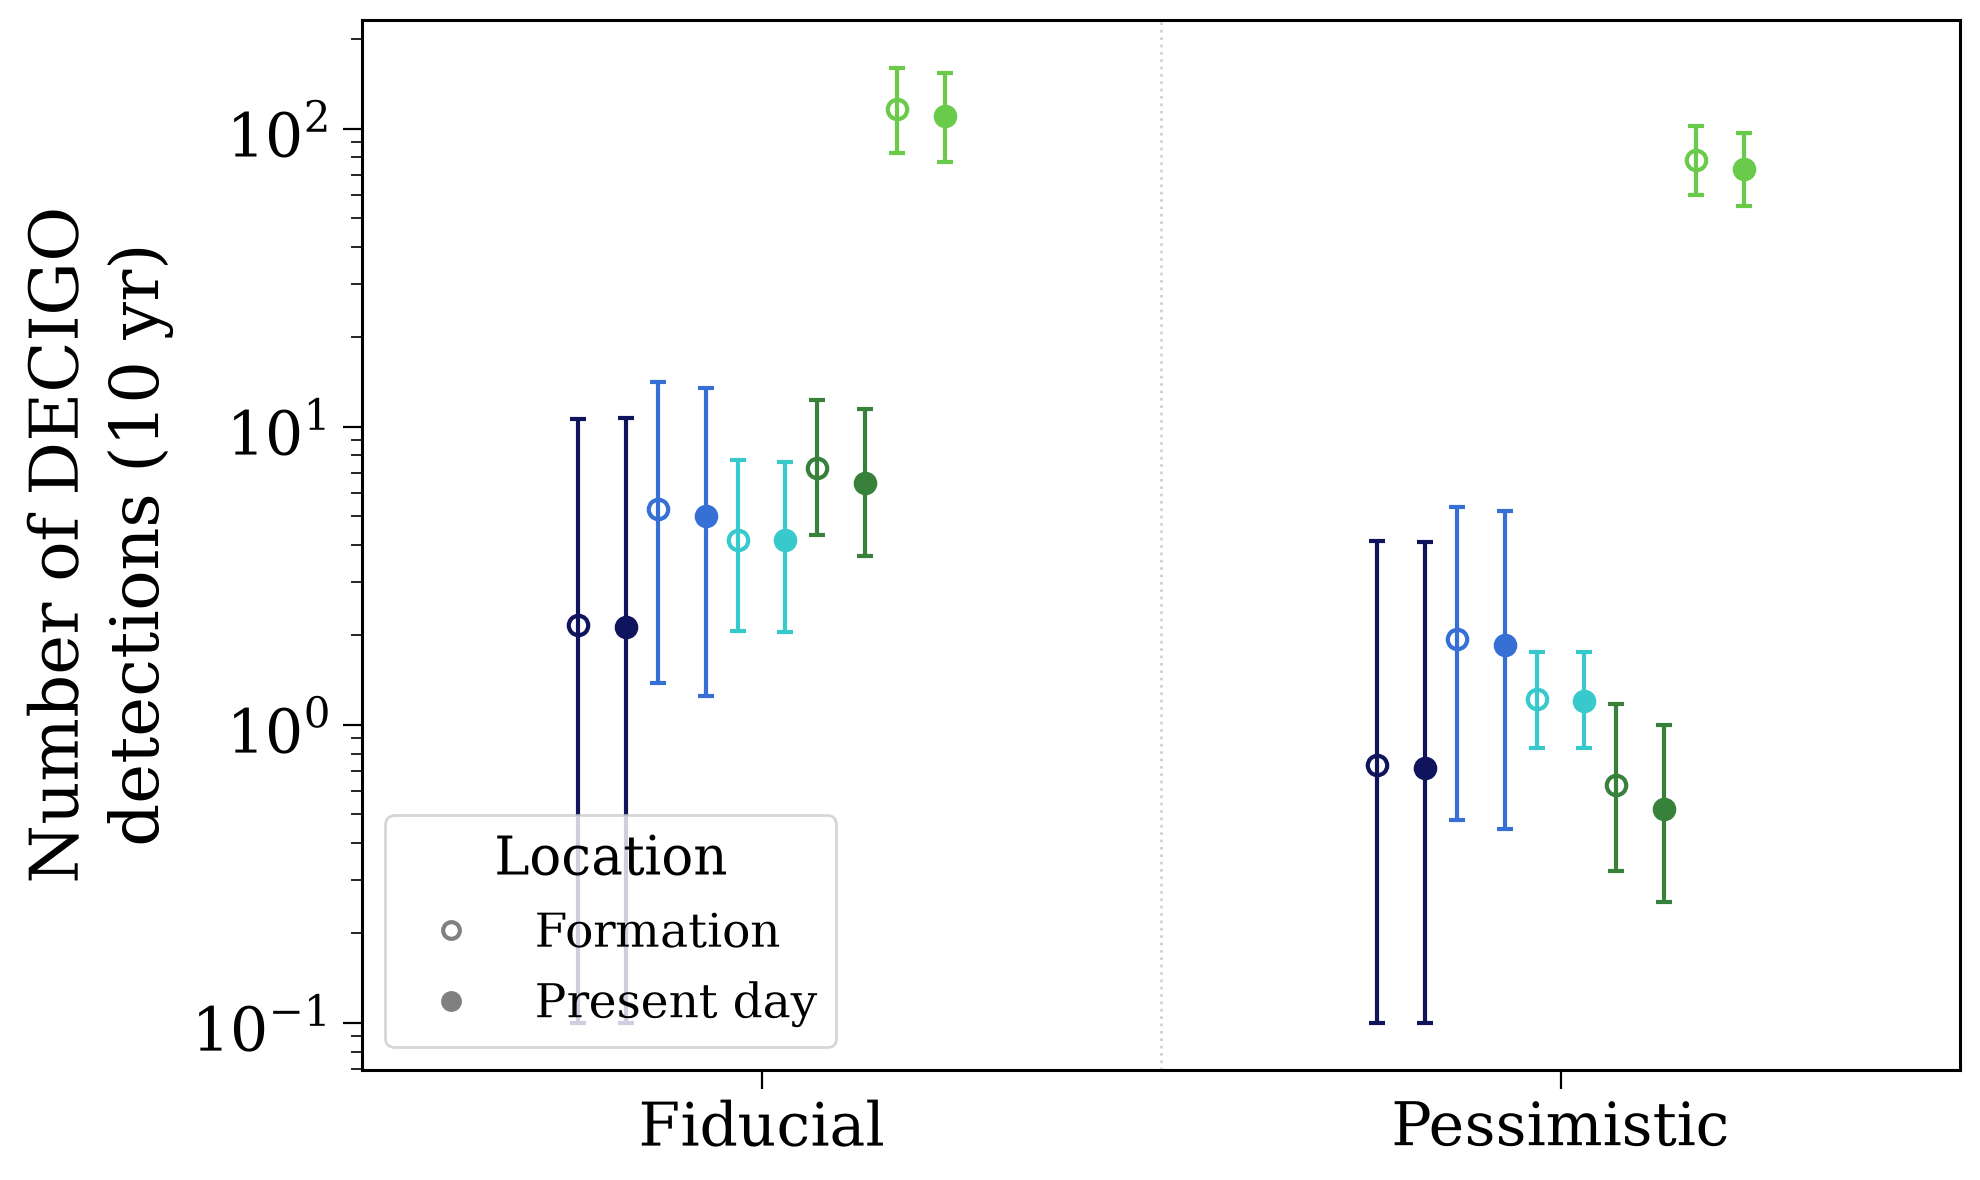

(<Figure size 1000x600 with 1 Axes>,
 <Axes: ylabel='Number of DECIGO\ndetections (10 yr)'>)

In [9]:
reload(detections)
detections.plot_detections(
    ["fiducial"], n_targets, detectors="decigo"
)

# Spatial plots

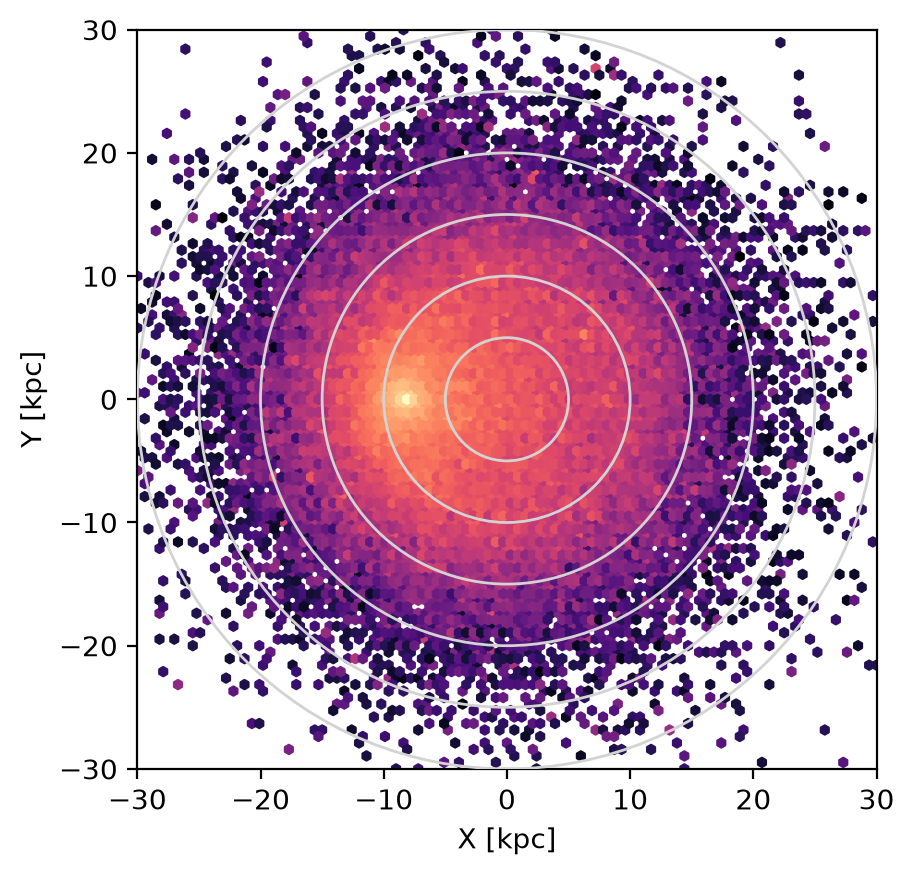

In [47]:
fig, ax = plt.subplots()
ax.hexbin(
    pop.final_pos[:, 0][pop.bpp["snr_lisa_10yr_final_pos"] > 7], pop.final_pos[:, 1][pop.bpp["snr_lisa_10yr_final_pos"] > 7],
    C=pop.initC["weights"][pop.bpp["snr_lisa_10yr_final_pos"] > 7],
    reduce_C_function=np.sum,
    extent=(-30, 30, -30, 30), bins="log", gridsize=100, cmap="magma"
)

radii = [5, 10, 15, 20, 25, 30]
for r in radii:
    circle = plt.Circle((0, 0), r, color="lightgrey", fill=False, zorder=10)
    ax.add_artist(circle)

ax.set(
    xlim=(-30, 30), ylim=(-30, 30), xlabel="X [kpc]", ylabel="Y [kpc]",
    aspect="equal"
)
plt.show()

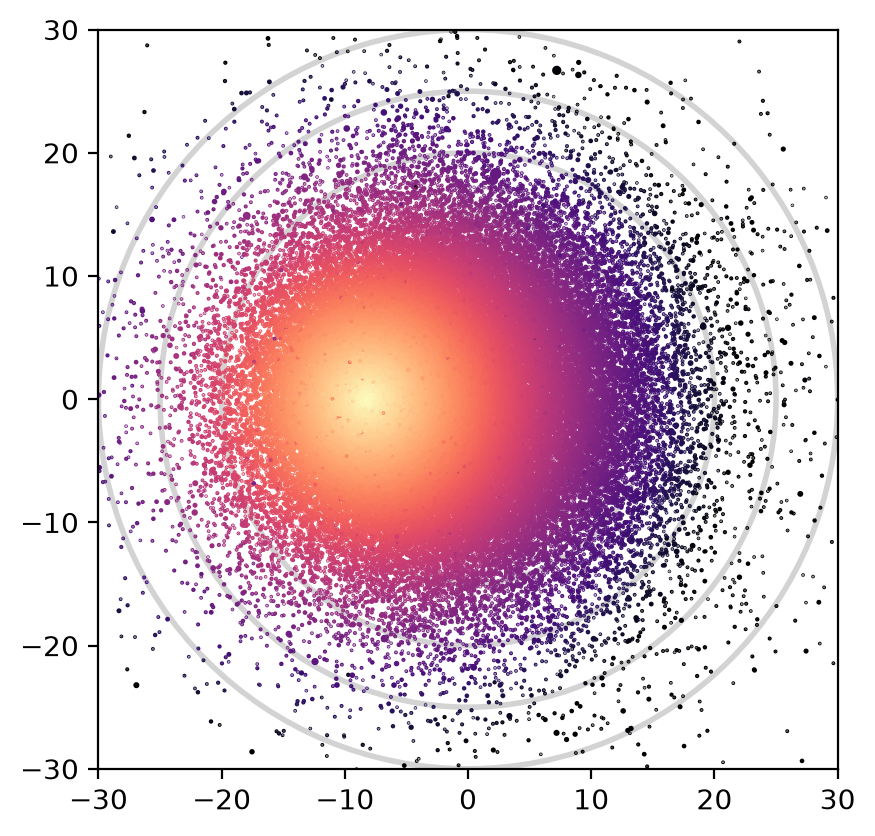

In [48]:
plt.scatter(pop.final_pos[:, 0][pop.bpp["snr_lisa_10yr_final_pos"] > 7], pop.final_pos[:, 1][pop.bpp["snr_lisa_10yr_final_pos"] > 7],
            s=5 * pop.initC["weights"][pop.bpp["snr_lisa_10yr_final_pos"] > 7], alpha=1,
            c=np.linalg.norm(pop.final_pos[pop.bpp["snr_lisa_10yr_final_pos"] > 7] - [-8.2, 0, 0] * u.kpc, axis=1), cmap="magma_r", vmin=0, vmax=30, rasterized=True)

# add circles of constant radius, 1, 5, 10, 15, 20, 25, 30 kpc
radii = [5, 10, 15, 20, 25, 30]
for r in radii:
    circle = plt.Circle((0, 0), r, color="lightgrey", fill=False, zorder=-1, lw=2)
    plt.gca().add_artist(circle)

plt.xlim(-30, 30)
plt.ylim(-30, 30)
plt.gca().set_aspect("equal")

In [29]:
import seaborn as sns

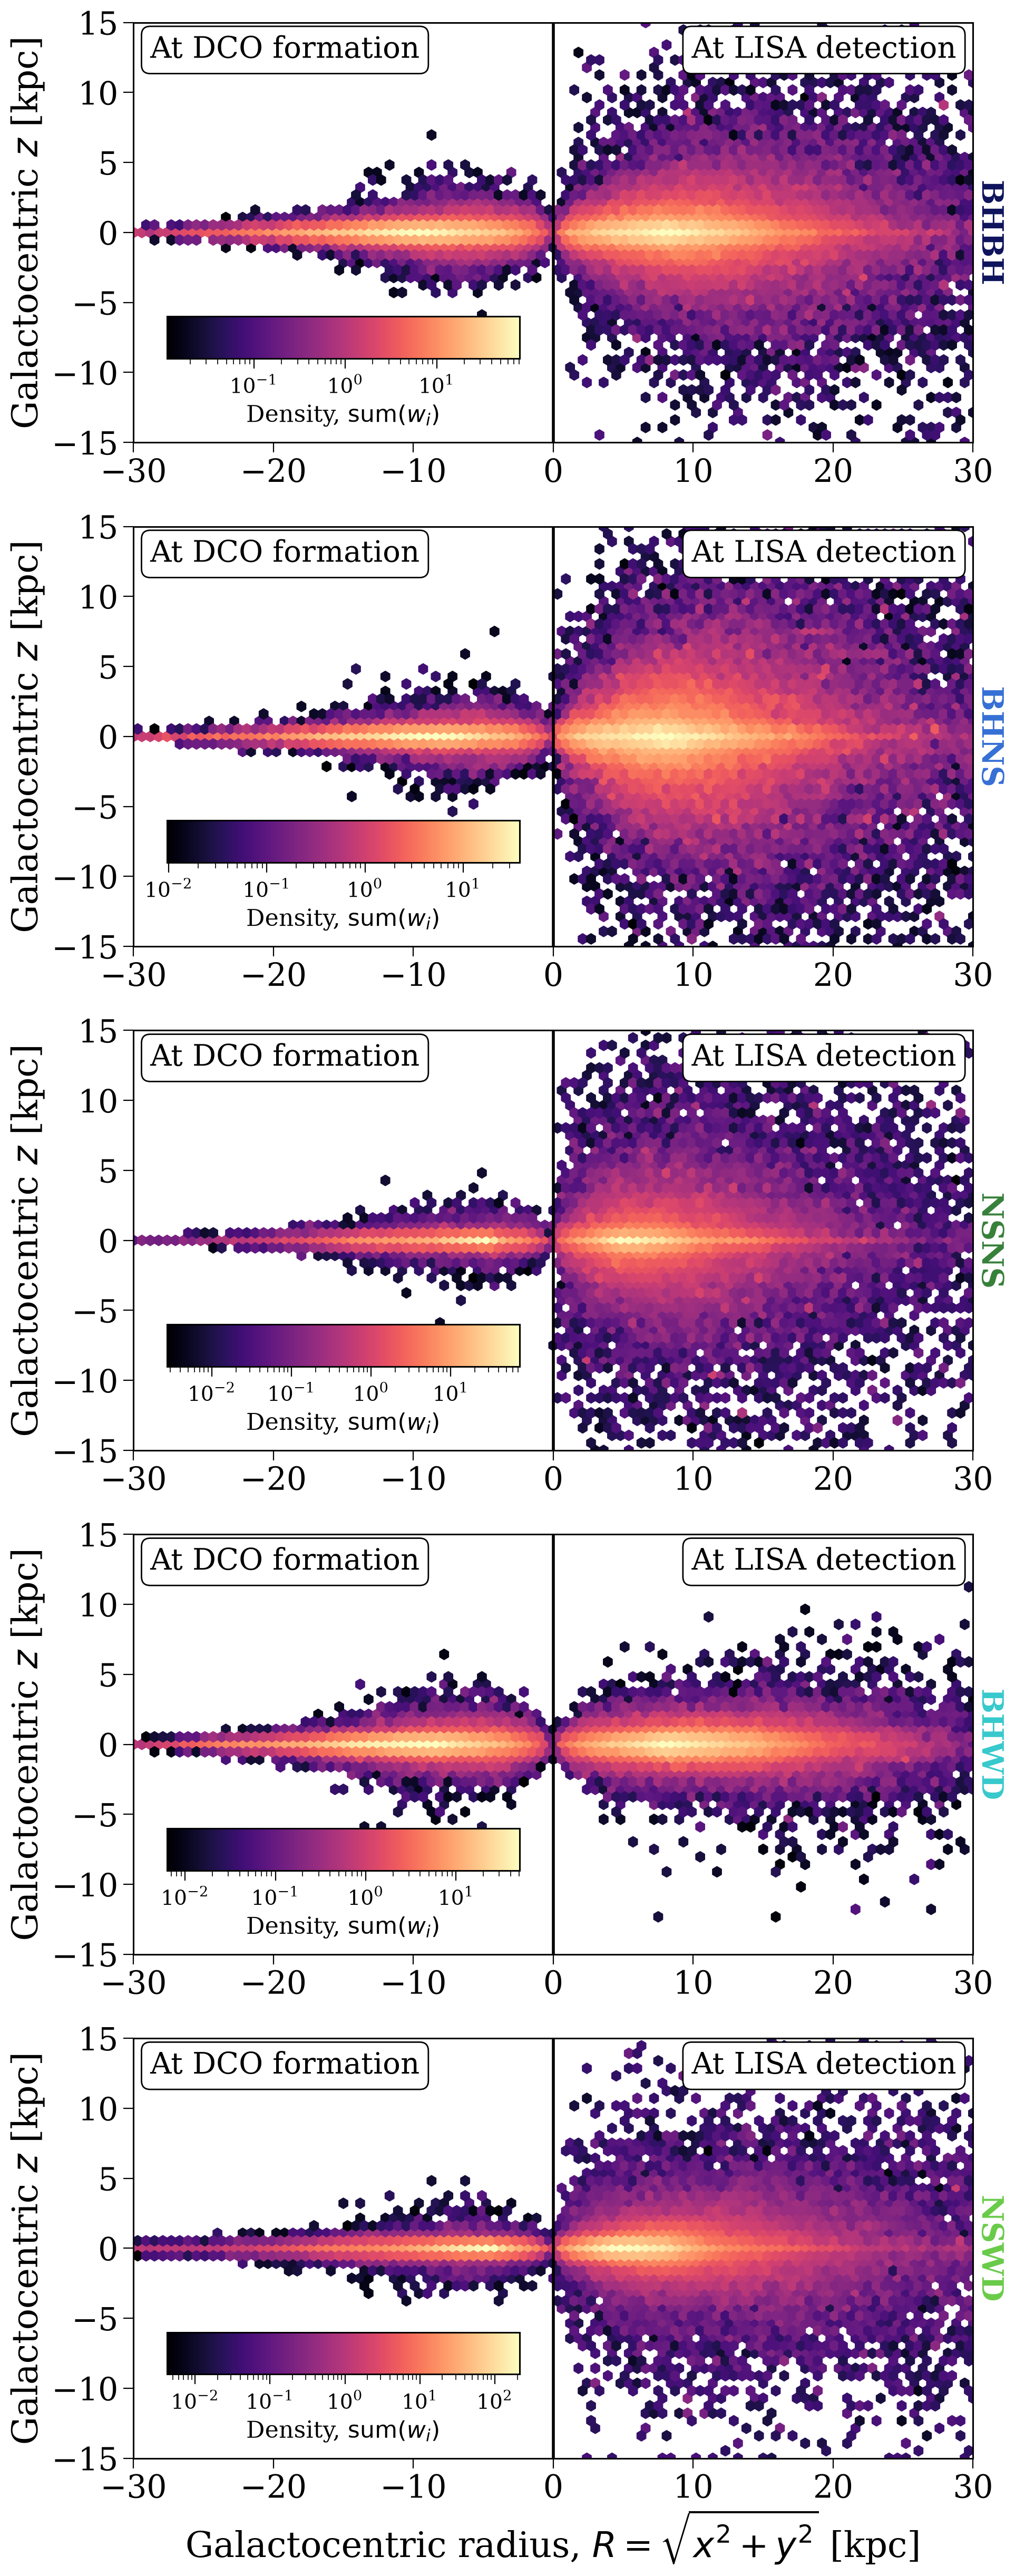

In [39]:
fig, axes = plt.subplots(5, 1, figsize=(14, 30))

ax = axes[0]

Z_MAX = 15

for ax, dco_type in zip(axes, ["BHBH", "BHNS", "NSNS", "BHWD", "NSWD"]):
    ax.set_aspect("equal")
    # if dco_type in ["BHWD", "NSWD"]:
    #     continue

    for x, z, extent in zip([-np.abs(lisa_pops[dco_type].initial_galaxy.rho), np.linalg.norm(lisa_pops[dco_type].final_pos[:, :2], axis=1)],
                            [lisa_pops[dco_type].initial_galaxy.z, lisa_pops[dco_type].final_pos[:, 2]],
                            [(-30, 0, -Z_MAX, Z_MAX), (0, 30, -Z_MAX, Z_MAX)]):
        hexbin = ax.hexbin(x, z, C=lisa_pops[dco_type].initC["weights"].values, reduce_C_function=np.sum, extent=extent, gridsize=50, bins="log", cmap="magma")# cmap=sns.dark_palette(const.DCO_COLOURS[dco_type], as_cmap=True, reverse=True))

    inset_ax = ax.inset_axes([0.04, 0.2, 0.42, 0.1])

    ax.axvline(0, color="k", ls="-", lw=2)

    cbar = fig.colorbar(hexbin, orientation="horizontal", cax=inset_ax)
    cbar.set_label(r"Density, ${\rm sum}(w_i)$", fontsize=16)
    cbar.ax.tick_params(labelsize=14)

    ax.annotate("At DCO formation", xy=(0.02, 0.97), xycoords="axes fraction", va="top", bbox=dict(boxstyle="round", facecolor="white"), fontsize=20)
    ax.annotate("At LISA detection", xy=(0.98, 0.97), xycoords="axes fraction", ha='right', va="top", bbox=dict(boxstyle="round", facecolor="white"), fontsize=20)

    ax.annotate(dco_type, xy=(1.02, 0.5), xycoords="axes fraction", ha='center', va="center", fontsize=20, rotation=270, color=const.DCO_COLOURS[dco_type], fontweight="bold")

    ax.set(
        ylabel=r"Galactocentric $z$ [kpc]", xlim=(-30, 30), ylim=(-Z_MAX, Z_MAX), aspect="equal"
    )
axes[-1].set_xlabel("Galactocentric radius, $R = \sqrt{x^2 + y^2}$ [kpc]")

plt.savefig("../plots/dco_positions.pdf", bbox_inches="tight", dpi=300)

plt.show()

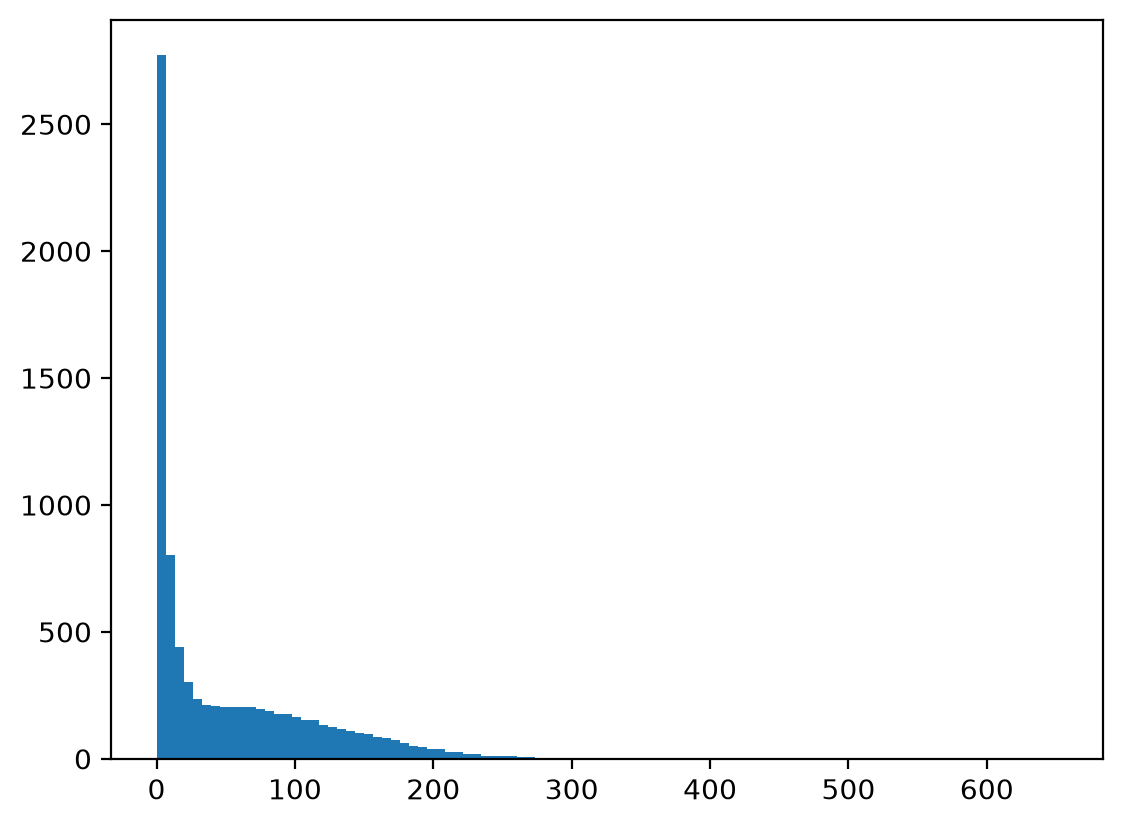

In [72]:
plt.hist(np.linalg.norm(lisa_pops["BHBH"].kick_info[["delta_vsysx_1", "delta_vsysy_1", "delta_vsysz_1"]], axis=1), weights=np.repeat(lisa_pops["BHBH"].initC["weights"].values, 2), bins=100);

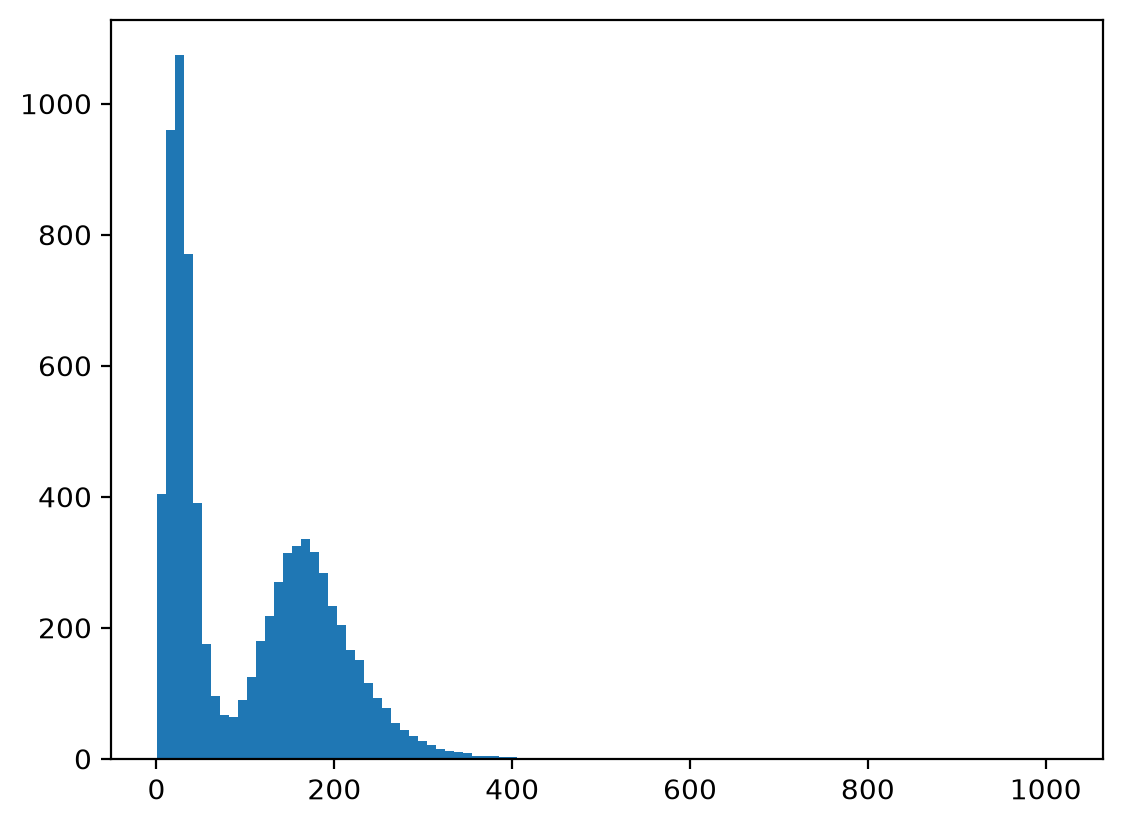

In [73]:
plt.hist(np.linalg.norm(lisa_pops["BHNS"].kick_info[["delta_vsysx_1", "delta_vsysy_1", "delta_vsysz_1"]], axis=1), weights=np.repeat(lisa_pops["BHNS"].initC["weights"].values, 2), bins=100);

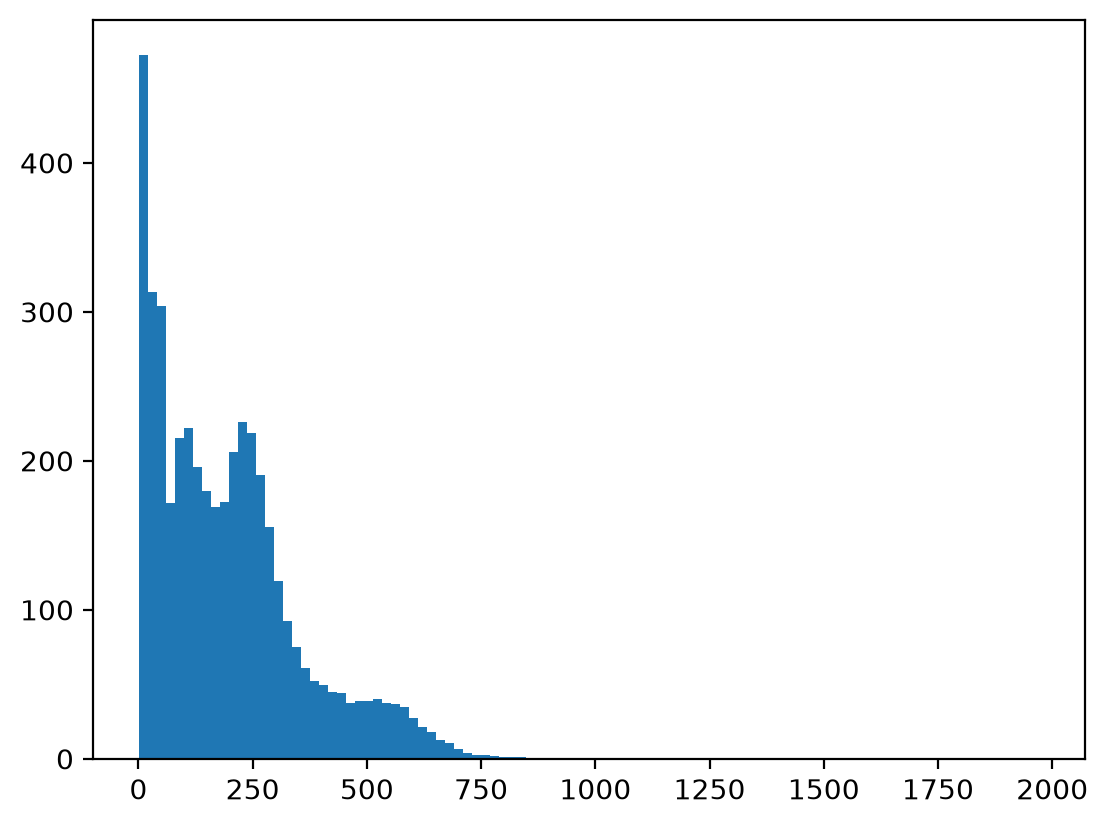

In [74]:
plt.hist(np.linalg.norm(lisa_pops["NSNS"].kick_info[["delta_vsysx_1", "delta_vsysy_1", "delta_vsysz_1"]], axis=1), weights=np.repeat(lisa_pops["NSNS"].initC["weights"].values, 2), bins=100);

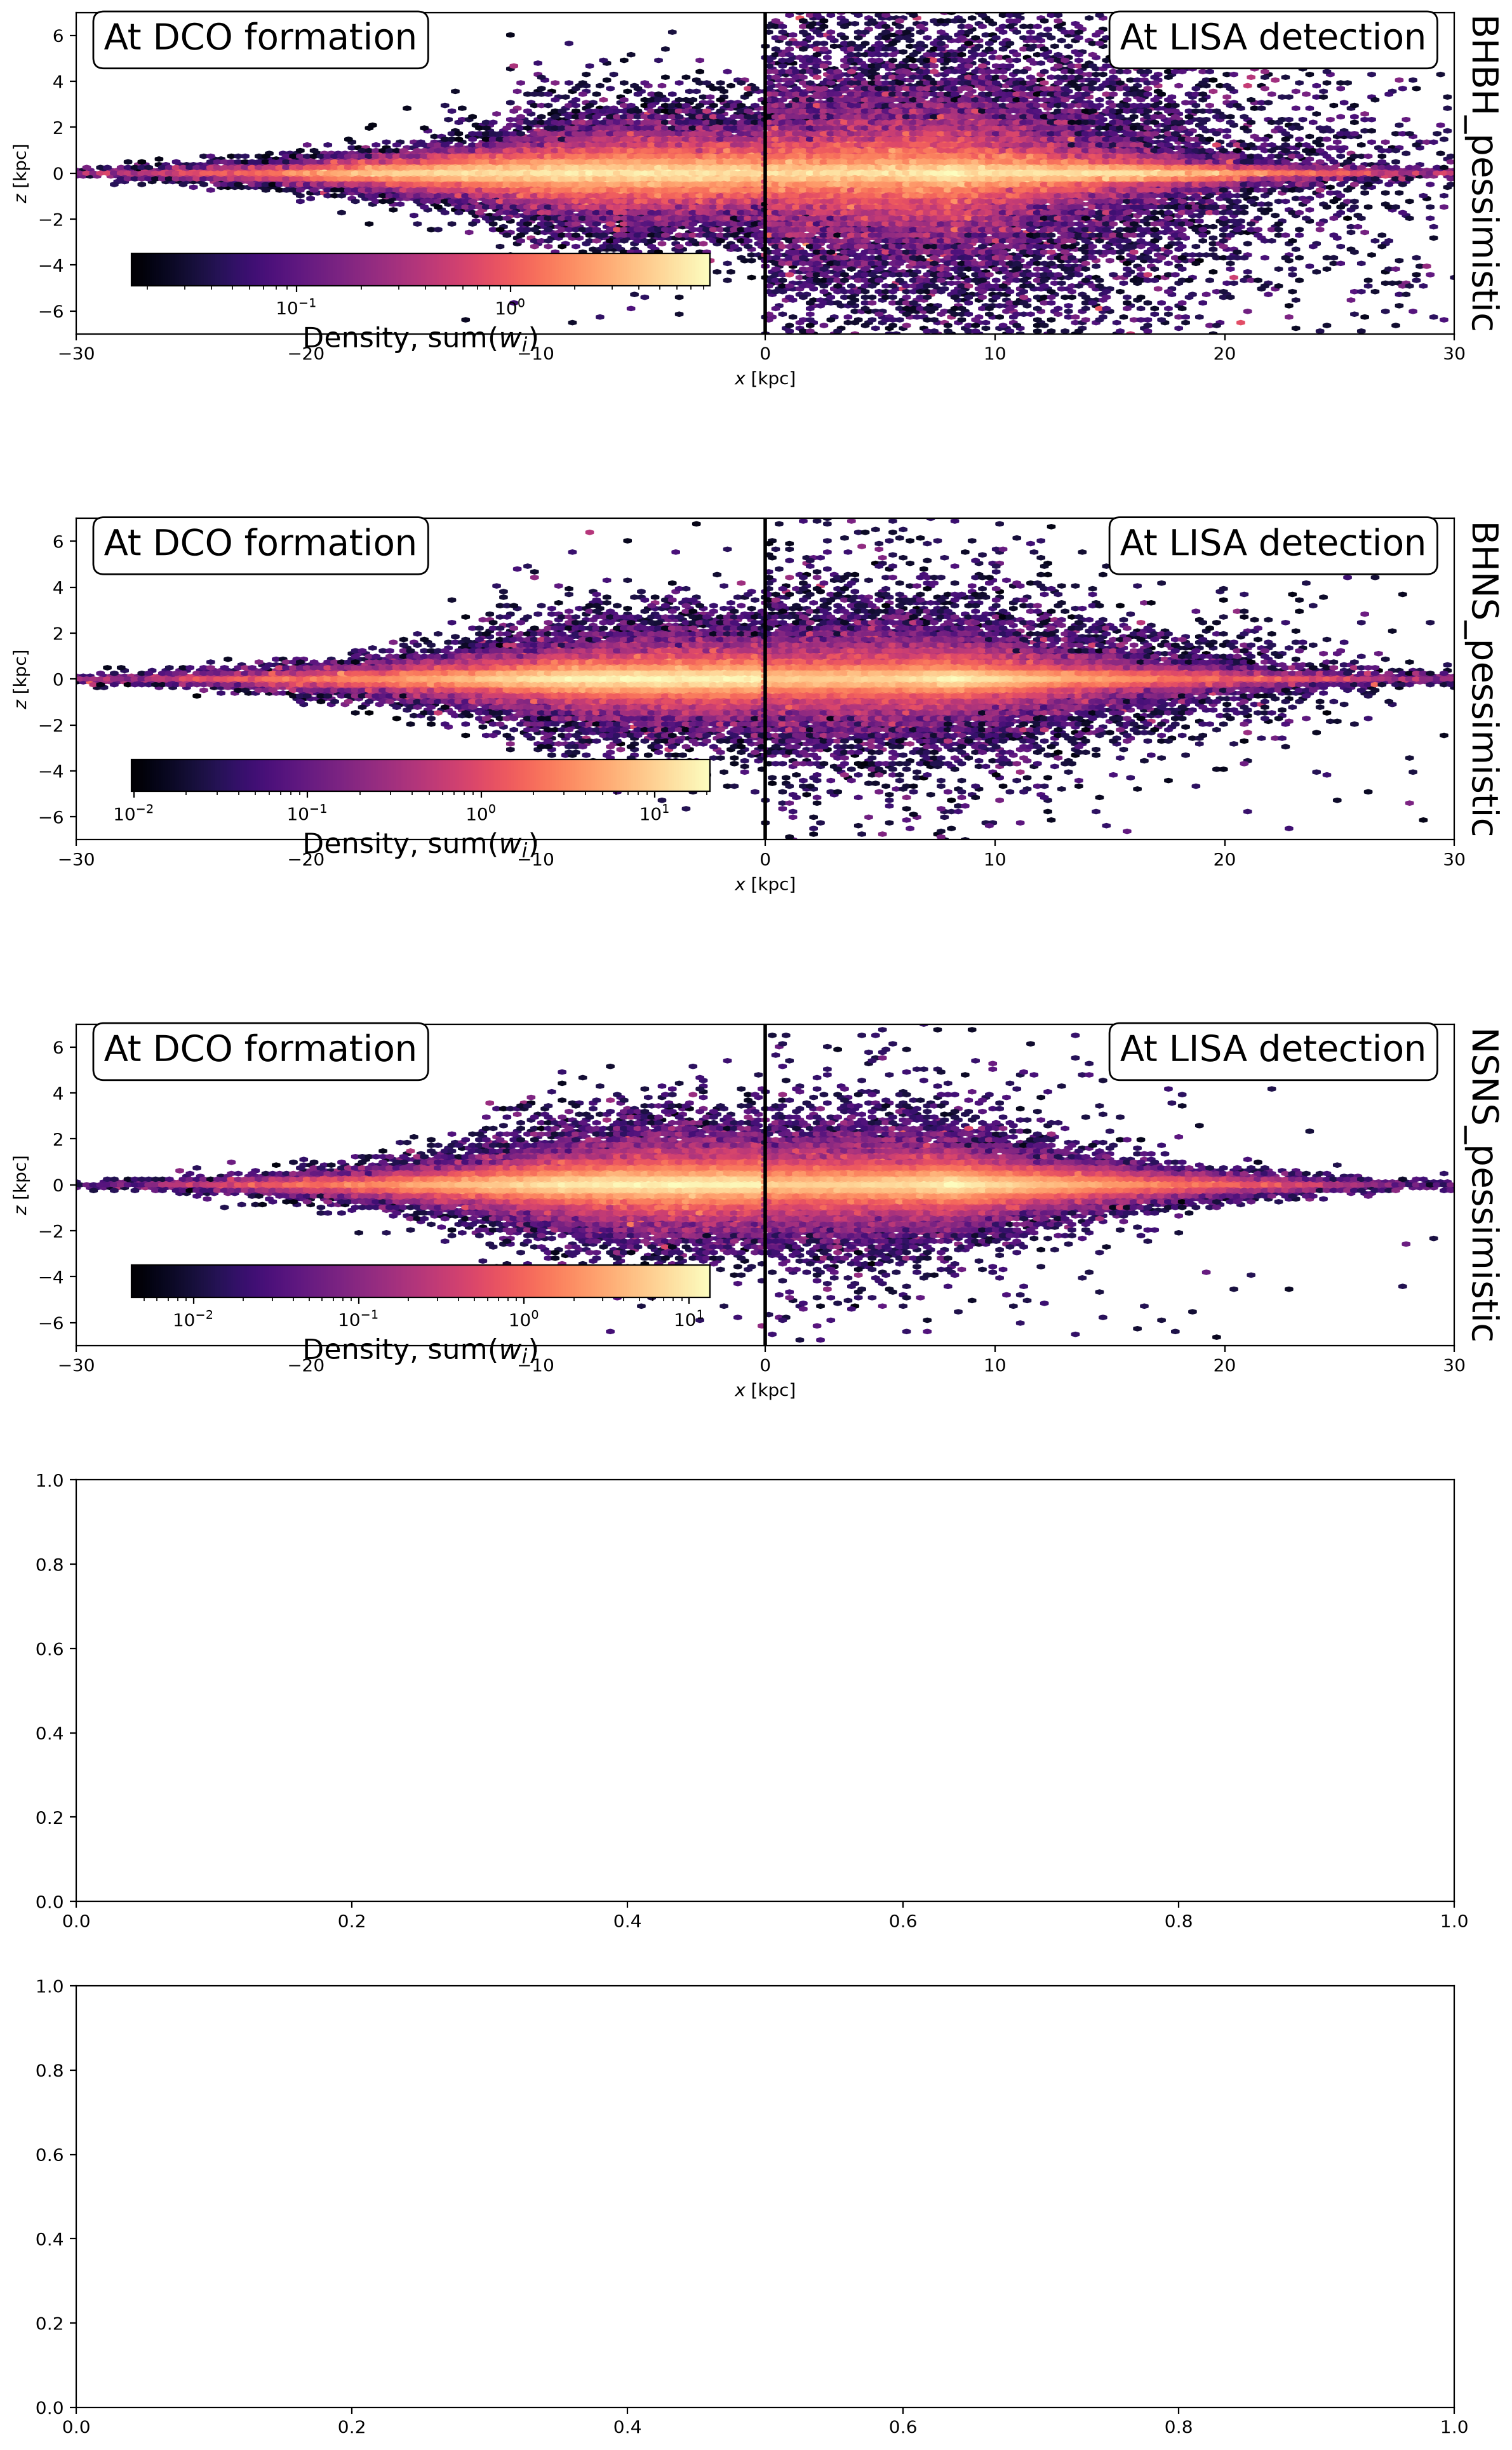

In [63]:
fig, axes = plt.subplots(5, 1, figsize=(14, 25))

ax = axes[0]

for ax, dco_type in zip(axes, ["BHBH", "BHNS", "NSNS", "BHWD", "NSWD"]):
    if dco_type in ["BHWD", "NSWD"]:
        continue
    dco_type = dco_type + "_pessimistic"

    for x, z, extent in zip([-np.abs(lisa_pops[dco_type].initial_galaxy.x), np.abs(lisa_pops[dco_type].final_pos[:, 0])],
                            [lisa_pops[dco_type].initial_galaxy.z, lisa_pops[dco_type].final_pos[:, 2]],
                            [(-30, 0, -7, 7), (0, 30, -7, 7)]):
        hexbin = ax.hexbin(x, z, C=lisa_pops[dco_type].initC["weights"].values, reduce_C_function=np.sum, extent=extent, bins="log", cmap="magma")

    inset_ax = ax.inset_axes([0.04, 0.15, 0.42, 0.1])

    ax.axvline(0, color="k", ls="-", lw=2)

    cbar = fig.colorbar(hexbin, orientation="horizontal", cax=inset_ax)
    cbar.set_label(r"Density, ${\rm sum}(w_i)$", fontsize=16)

    ax.annotate("At DCO formation", xy=(0.02, 0.97), xycoords="axes fraction", va="top", bbox=dict(boxstyle="round", facecolor="white"), fontsize=20)
    ax.annotate("At LISA detection", xy=(0.98, 0.97), xycoords="axes fraction", ha='right', va="top", bbox=dict(boxstyle="round", facecolor="white"), fontsize=20)

    ax.annotate(dco_type, xy=(1.02, 0.5), xycoords="axes fraction", ha='center', va="center", fontsize=20, rotation=270)

    ax.set(
        xlabel=r"$x$ [kpc]", ylabel=r"$z$ [kpc]", xlim=(-30, 30), ylim=(-7, 7), aspect="equal"
    )

plt.show()

In [2]:
fig, axes = plt.subplots(5, 1, figsize=(14, 35))

ax = axes[0]

for ax, dco_type in zip(axes, ["BHBH", "BHNS", "NSNS", "BHWD", "NSWD"]):

    for x, z, extent in zip([-np.abs(pop.initial_galaxy.x), np.abs(pop.final_pos[:, 0])], [pop.initial_galaxy.z, pop.final_pos[:, 2]], [(-30, 0, -15, 15), (0, 30, -15, 15)]):
        hexbin = ax.hexbin(x, z, C=pop.initC["weights"].values, reduce_C_function=np.sum, extent=extent, cmap="magma")

    inset_ax = ax.inset_axes([0.04, 0.15, 0.42, 0.1])

    ax.axvline(0, color="k", ls="-", lw=2)

    cbar = fig.colorbar(hexbin, orientation="horizontal", cax=inset_ax)
    cbar.set_label(r"Density, ${\rm sum}(w_i)$", fontsize=16)

    ax.annotate("At DCO formation", xy=(0.02, 0.97), xycoords="axes fraction", va="top", bbox=dict(boxstyle="round", facecolor="white"), fontsize=20)
    ax.annotate("At LISA detection", xy=(0.98, 0.97), xycoords="axes fraction", ha='right', va="top", bbox=dict(boxstyle="round", facecolor="white"), fontsize=20)

    ax.annotate(dco_type, xy=(1.02, 0.5), xycoords="axes fraction", ha='center', va="center", fontsize=20, rotation=270)

    ax.set(
        xlabel=r"$x$ [kpc]", ylabel=r"$z$ [kpc]", xlim=(-30, 30), ylim=(-15, 15), aspect="equal"
    )

plt.show()

NameError: name 'plt' is not defined

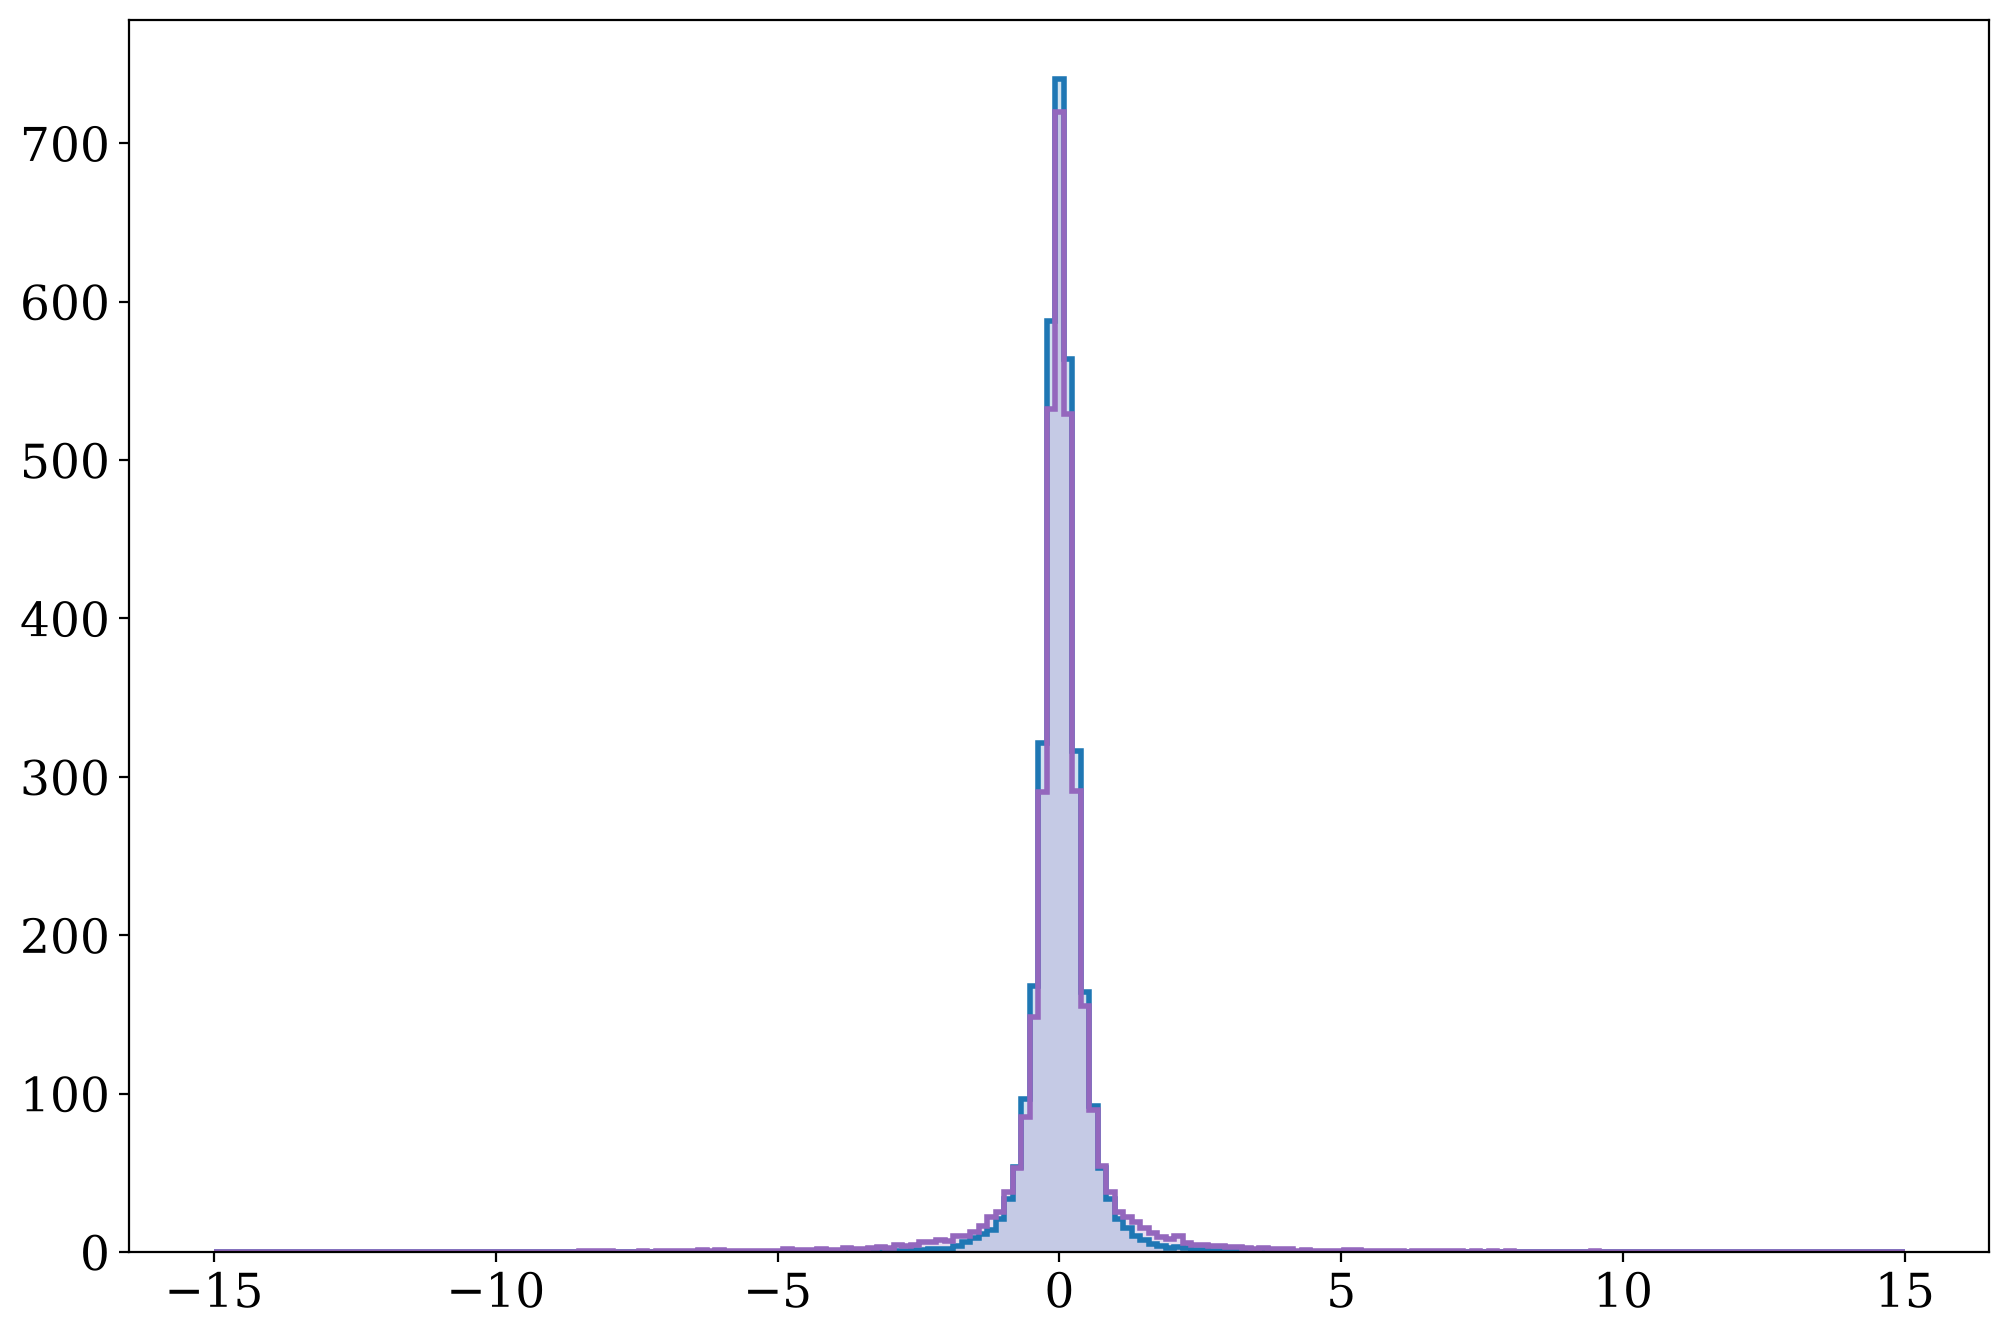

In [14]:
bins = np.linspace(-15, 15, 200)

plt.hist(pop.initial_galaxy.z.value, weights=pop.initC["weights"], bins=bins, histtype="step", lw=2);
plt.hist(pop.final_pos[:, 2].value, weights=pop.initC["weights"], bins=bins, histtype="step", lw=2, color="C4");
plt.hist(pop.initial_galaxy.z.value, weights=pop.initC["weights"], bins=bins, alpha=0.2, color="C0");
plt.hist(pop.final_pos[:, 2].value, weights=pop.initC["weights"], bins=bins, alpha=0.2, color="C4");
# plt.yscale("log")

# LISA source plots

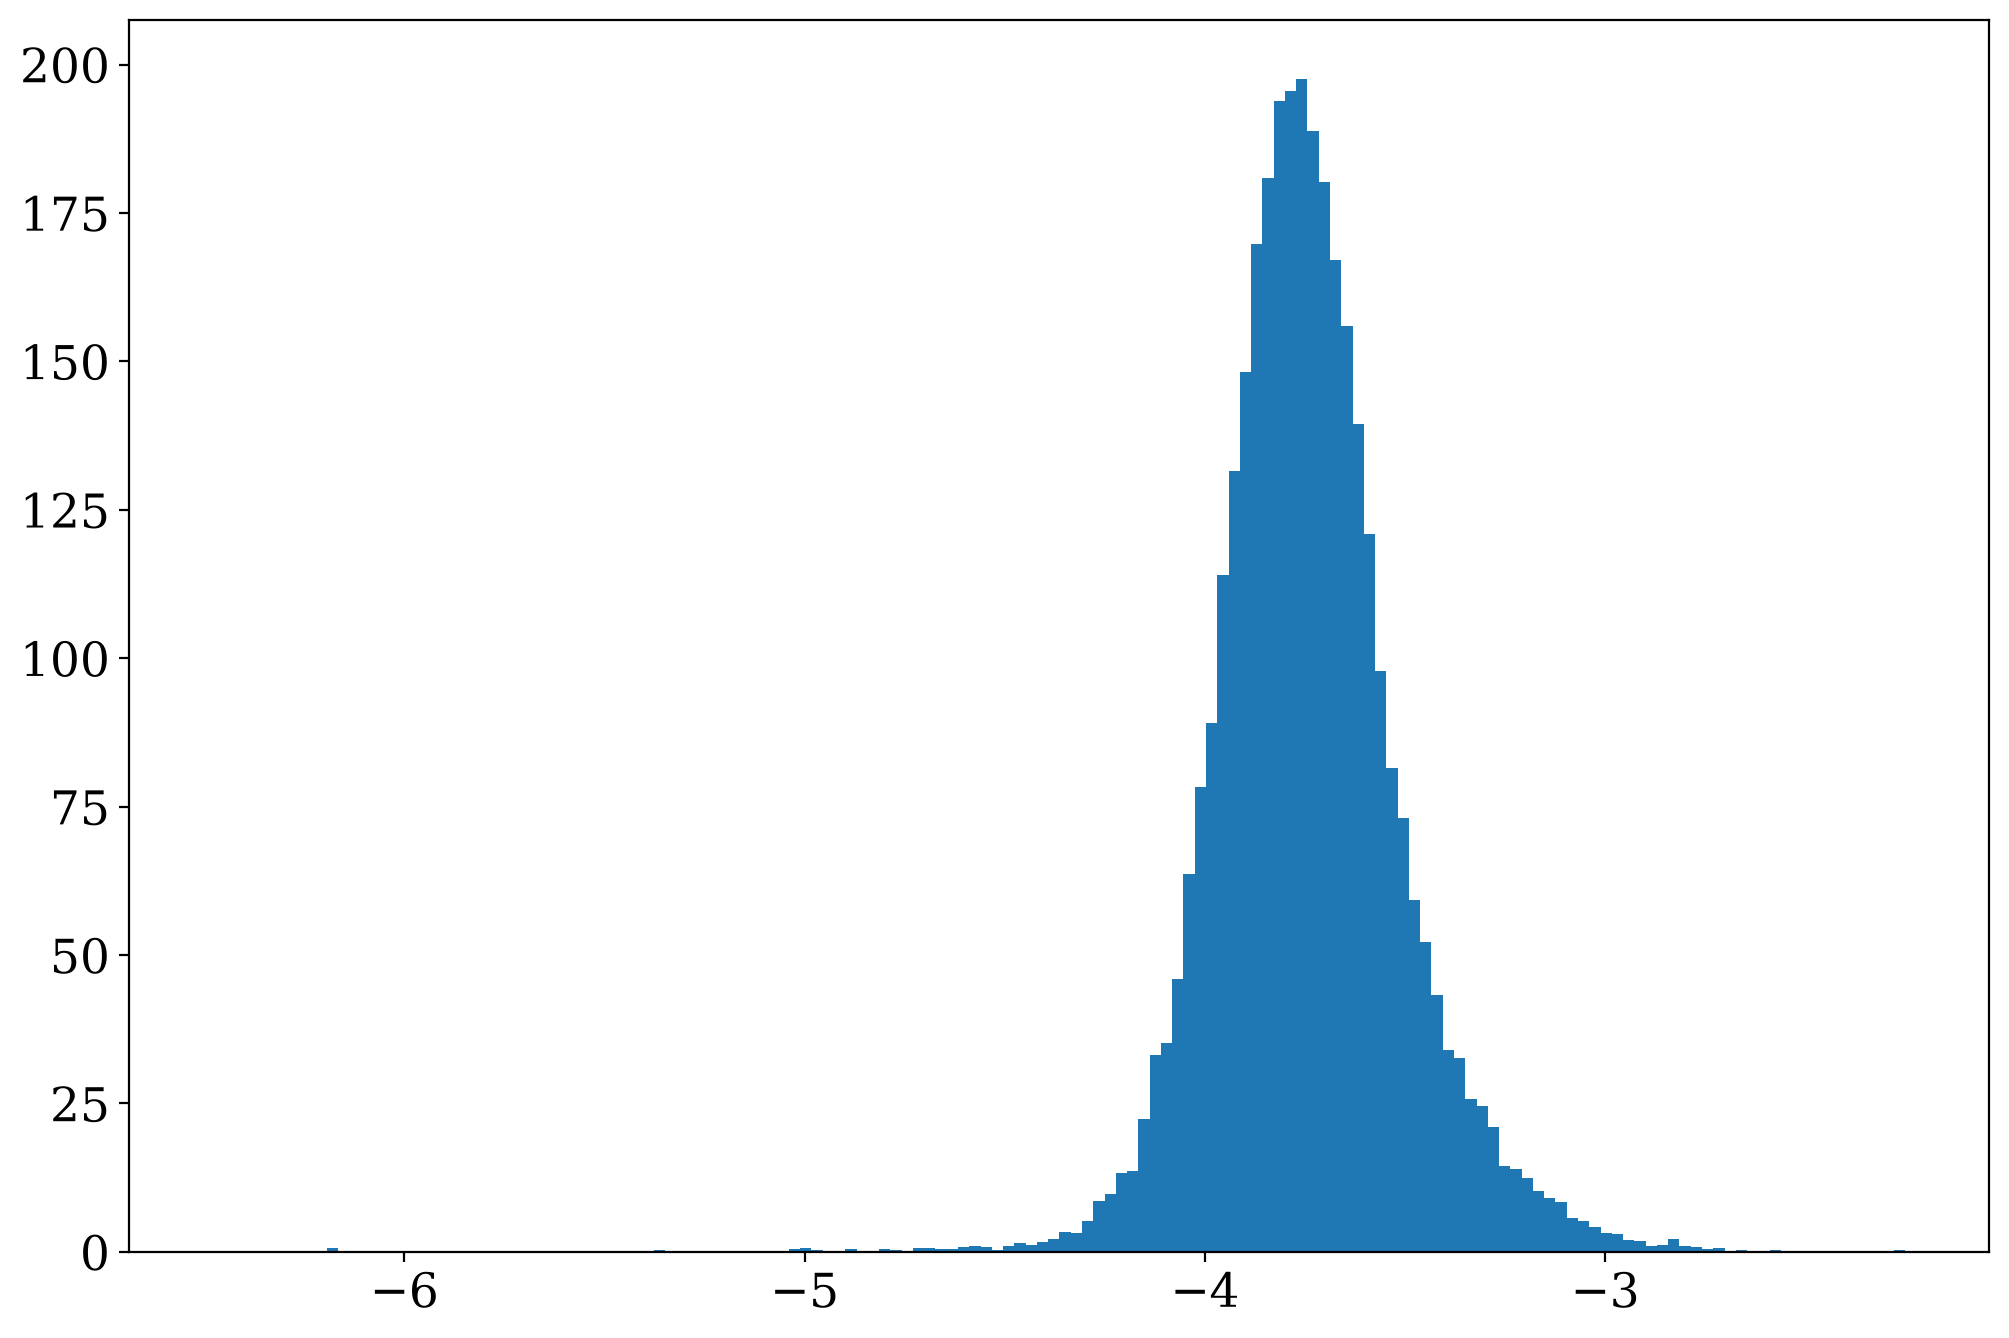

In [15]:
plt.hist(np.log10(sources.f_orb.value), weights=pop.initC["weights"], bins=150);

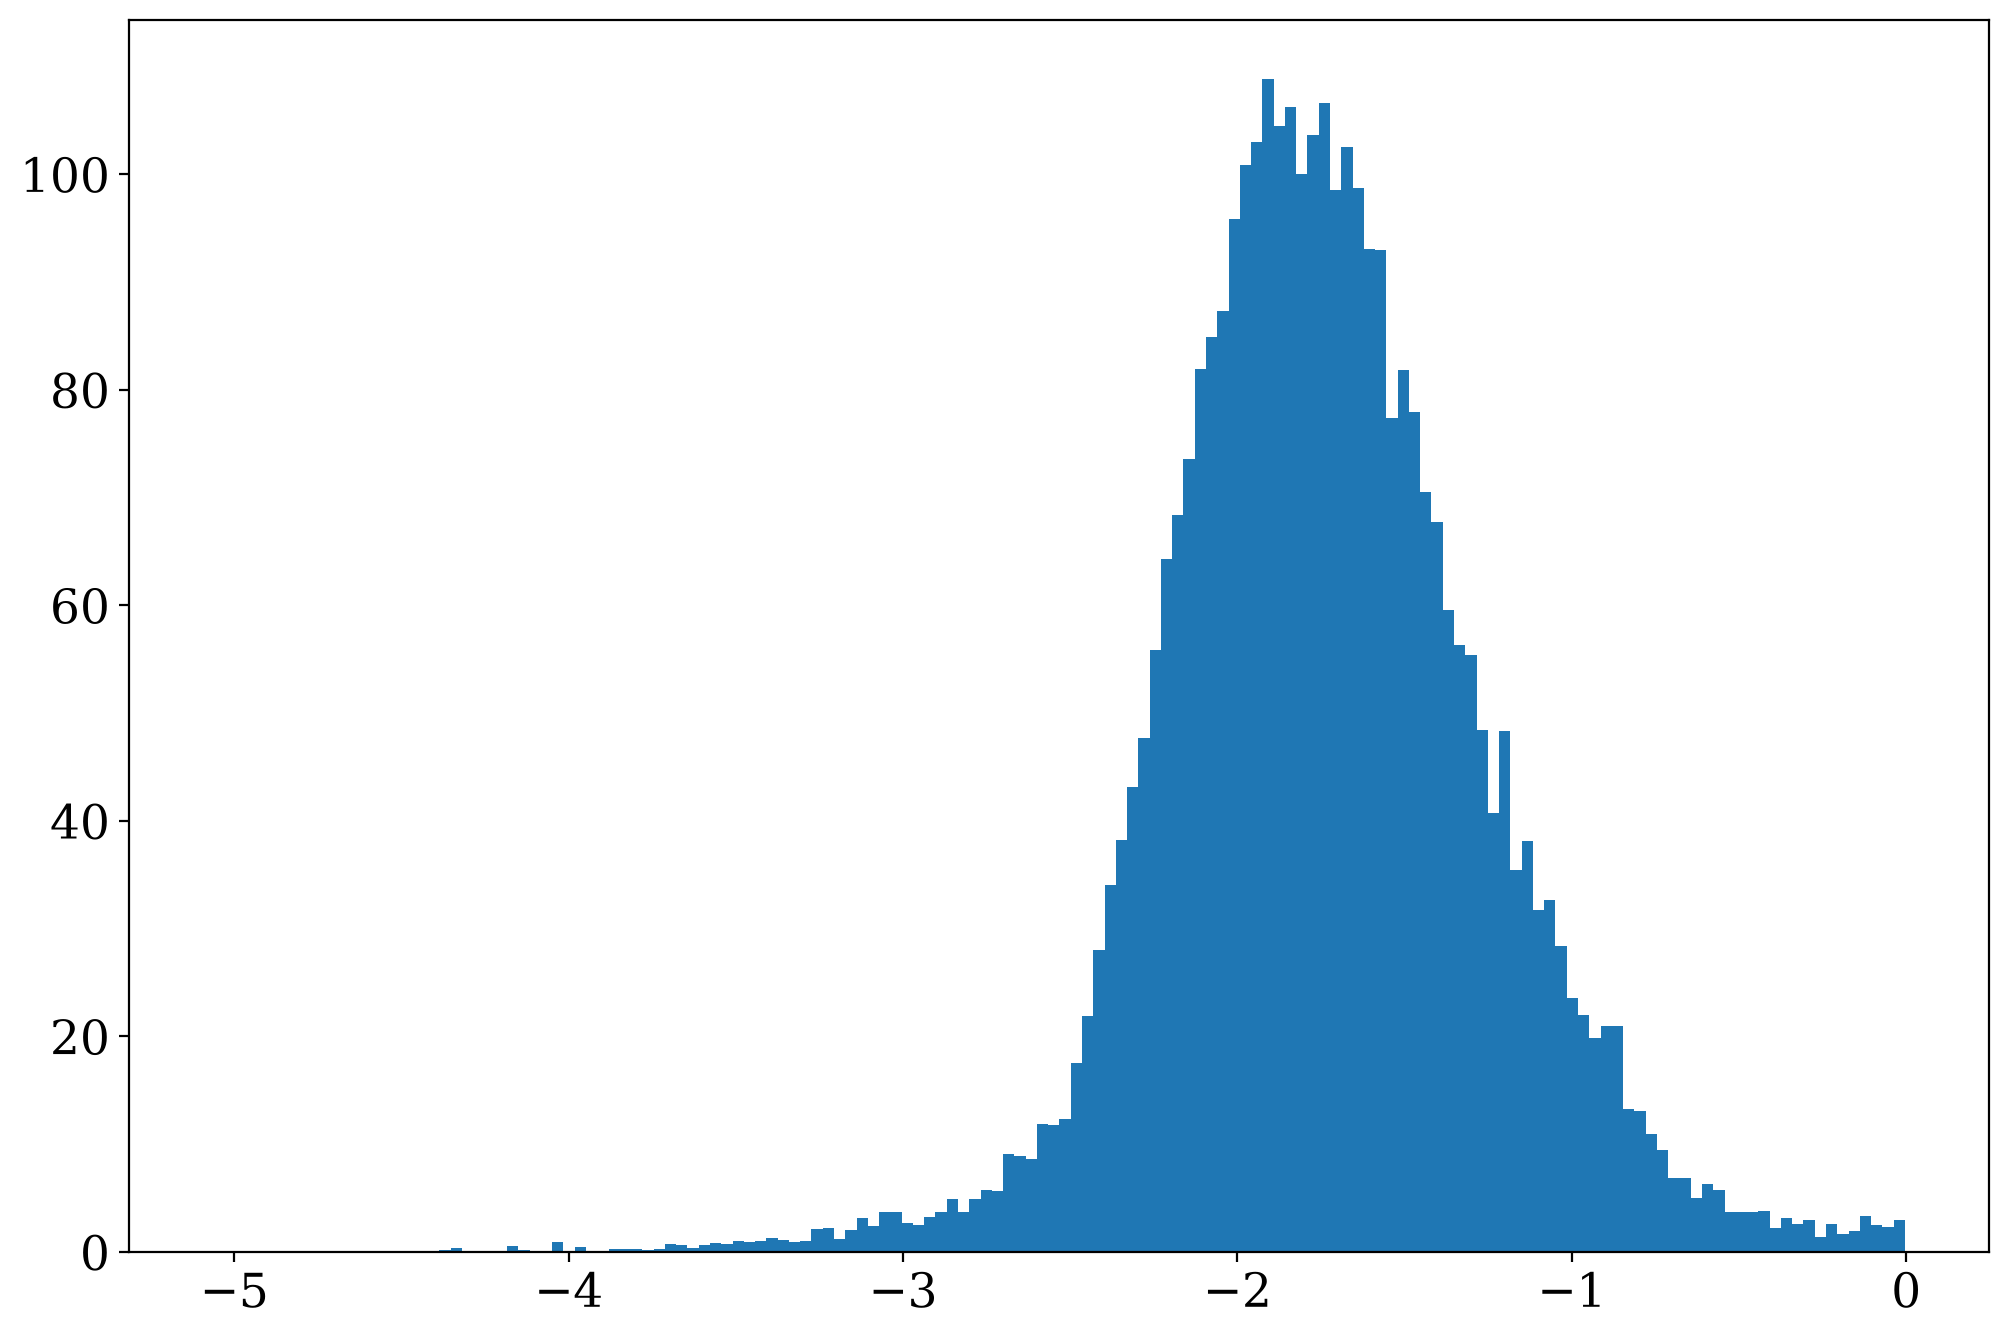

In [16]:
plt.hist(np.log10(sources.ecc), weights=pop.initC["weights"], bins=150);

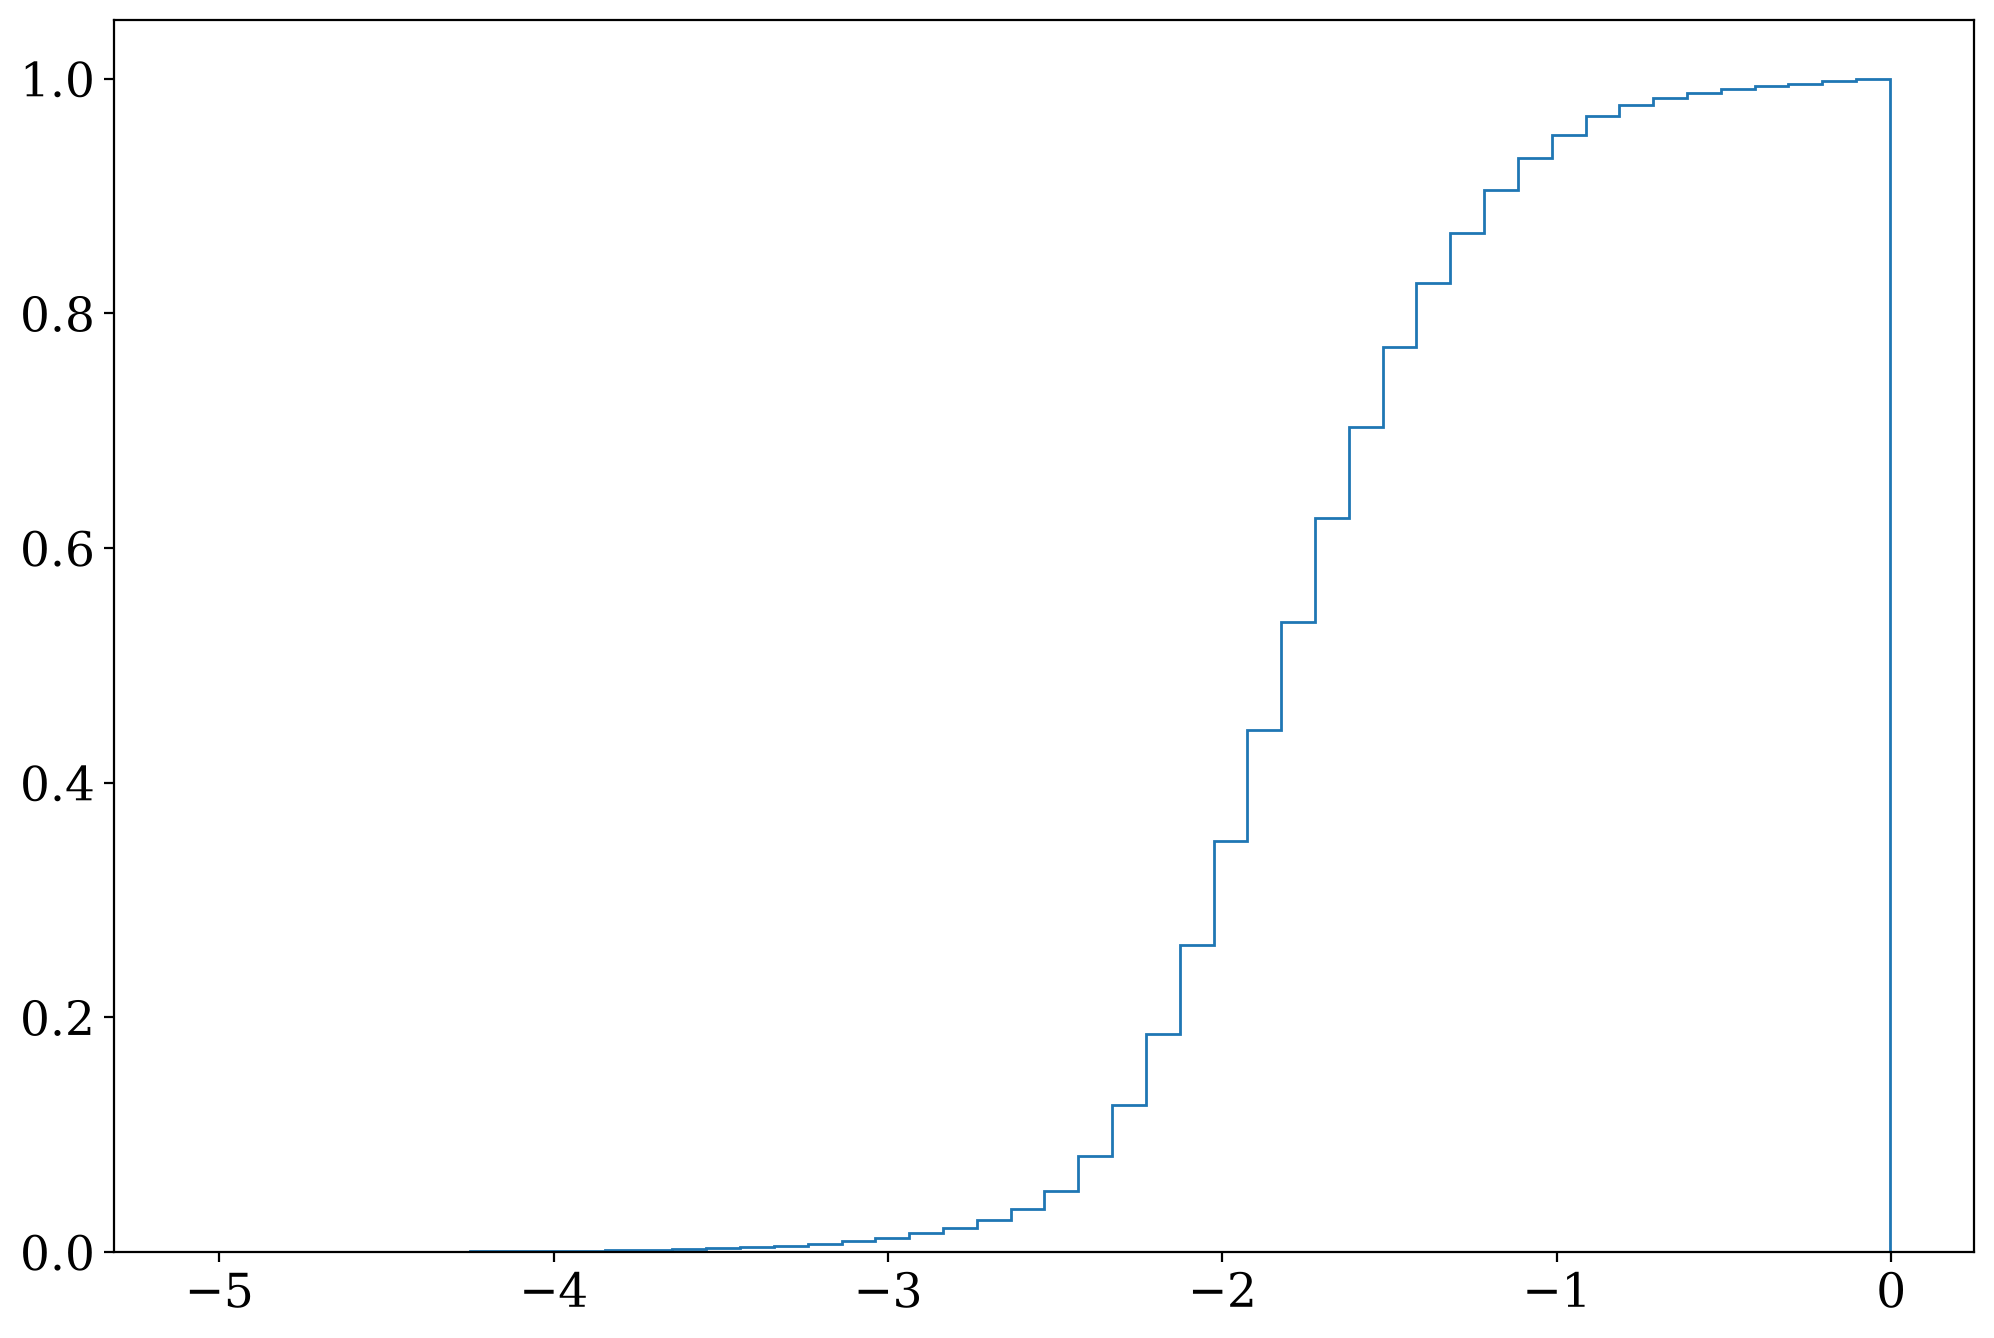

In [17]:
plt.hist(np.log10(sources.ecc), weights=pop.initC["weights"], bins=50, cumulative=True, density=True, histtype="step", label="Cumulative Distribution");

# Uncertainties

In [44]:
import uncertainties as unc
snr_uncertainty, snr_ratio, detectable_harmonics, max_harmonics = unc.get_ecc_uncertainty_stats(sources, harmonic_threshold=2)
min_ratio = np.clip(snr_ratio - snr_uncertainty, 0, None)

<Quantity [3.01077984e-10, 4.28239543e-10, 5.90191278e-10, ...,
           1.65532423e-11, 9.67761943e-12, 1.54332084e-11] Hz / yr>

In [73]:
sigma_m_c = unc.get_m_c_uncertainty(
    sources.f_orb,
    lw.utils.fn_dot(sources.m_c, sources.f_orb, sources.ecc, n=1),
    sources.ecc,
    snr_uncertainty,
    sources.snr,
    4 * u.yr
)
sky_localisation = unc.sky_localisation(
    sources.snr,
    sources.f_orb * 2,
)

In [54]:
(sigma_m_c < 1).sum() / len(sources)

np.float64(0.2820031144177769)

In [81]:
theta = np.arctan(np.abs(pop.final_pos[:, 2]) / sources.dist).to(u.deg)
sigma_theta = sky_localisation / theta

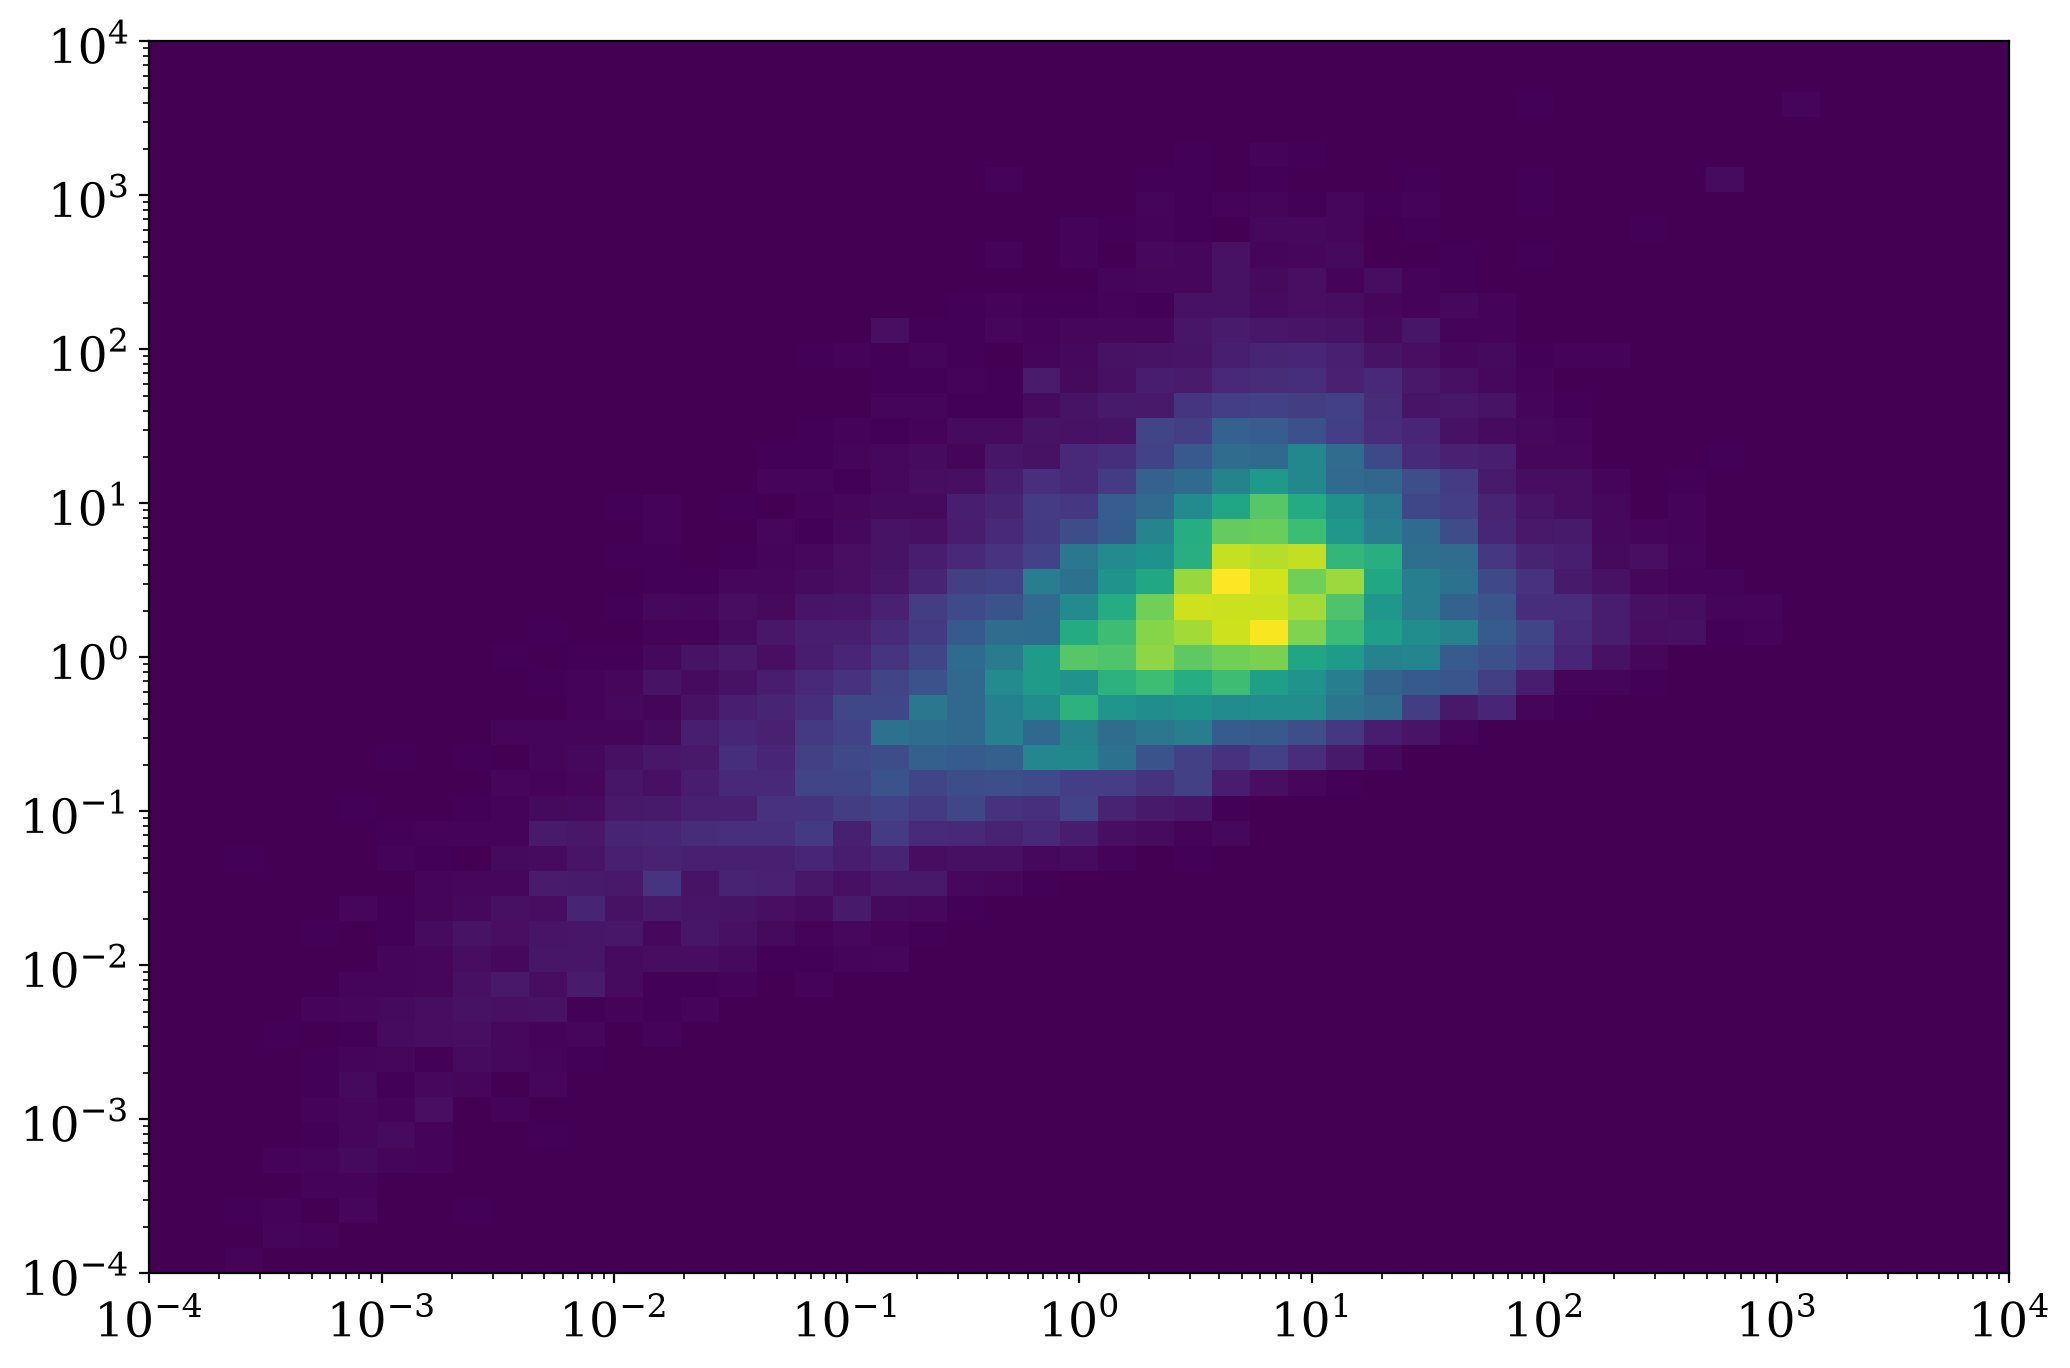

In [109]:
fig, ax = plt.subplots()

# ax.scatter(sigma_m_c, sigma_theta, s=10 * pop.initC["weights"])
ax.hist2d(
    sigma_m_c, sigma_theta, weights=pop.initC["weights"],
    bins=(np.logspace(-4, 4, 50), np.logspace(-4, 4, 50)),
)

ax.set(
    xscale="log", yscale="log"
)

plt.show()

In [92]:
massive = (sources.m_c - sigma_m_c * sources.m_c) > 1.2 * u.Msun
np.sum(pop.initC["weights"][massive]) / np.sum(pop.initC["weights"])

np.float64(0.26309124575862025)

In [93]:
away_from_plane = np.arcsin(1 * u.kpc / sources.dist) - sky_localisation > 0 * u.deg
np.sum(pop.initC["weights"][away_from_plane]) / np.sum(pop.initC["weights"])

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in arcsin
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)



np.float64(0.35030998842773653)

[None, None]

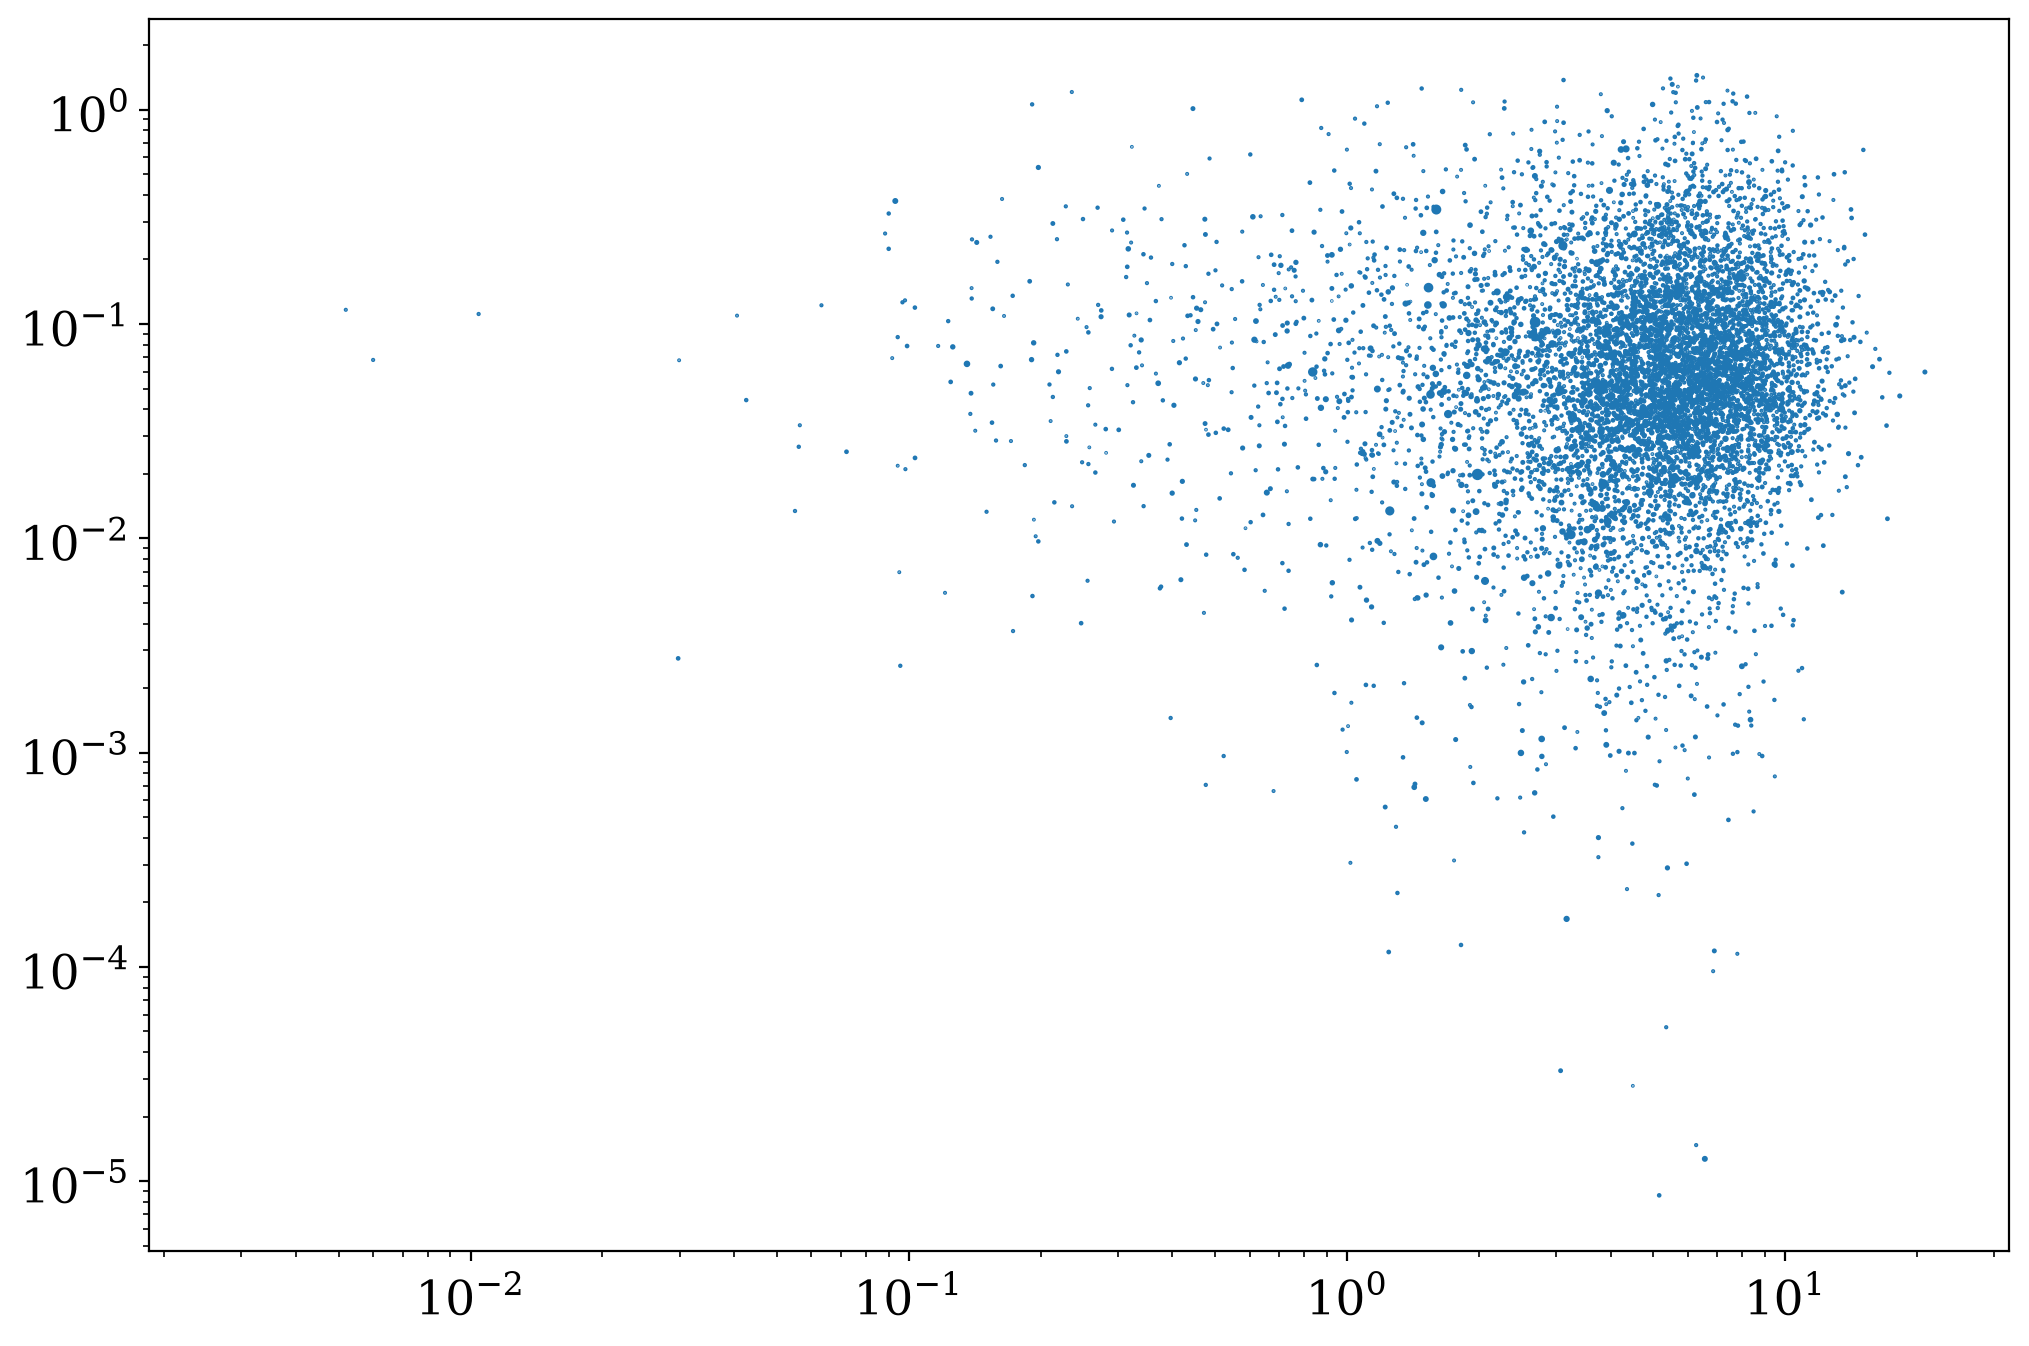

In [94]:
fig, ax = plt.subplots()

ax.scatter(sources.m_c - sigma_m_c * sources.m_c - 1.2 * u.Msun, np.arcsin(1 * u.kpc / sources.dist) - sky_localisation, s=10 * pop.initC["weights"])

ax.set(
    xscale="log", yscale="log"
)

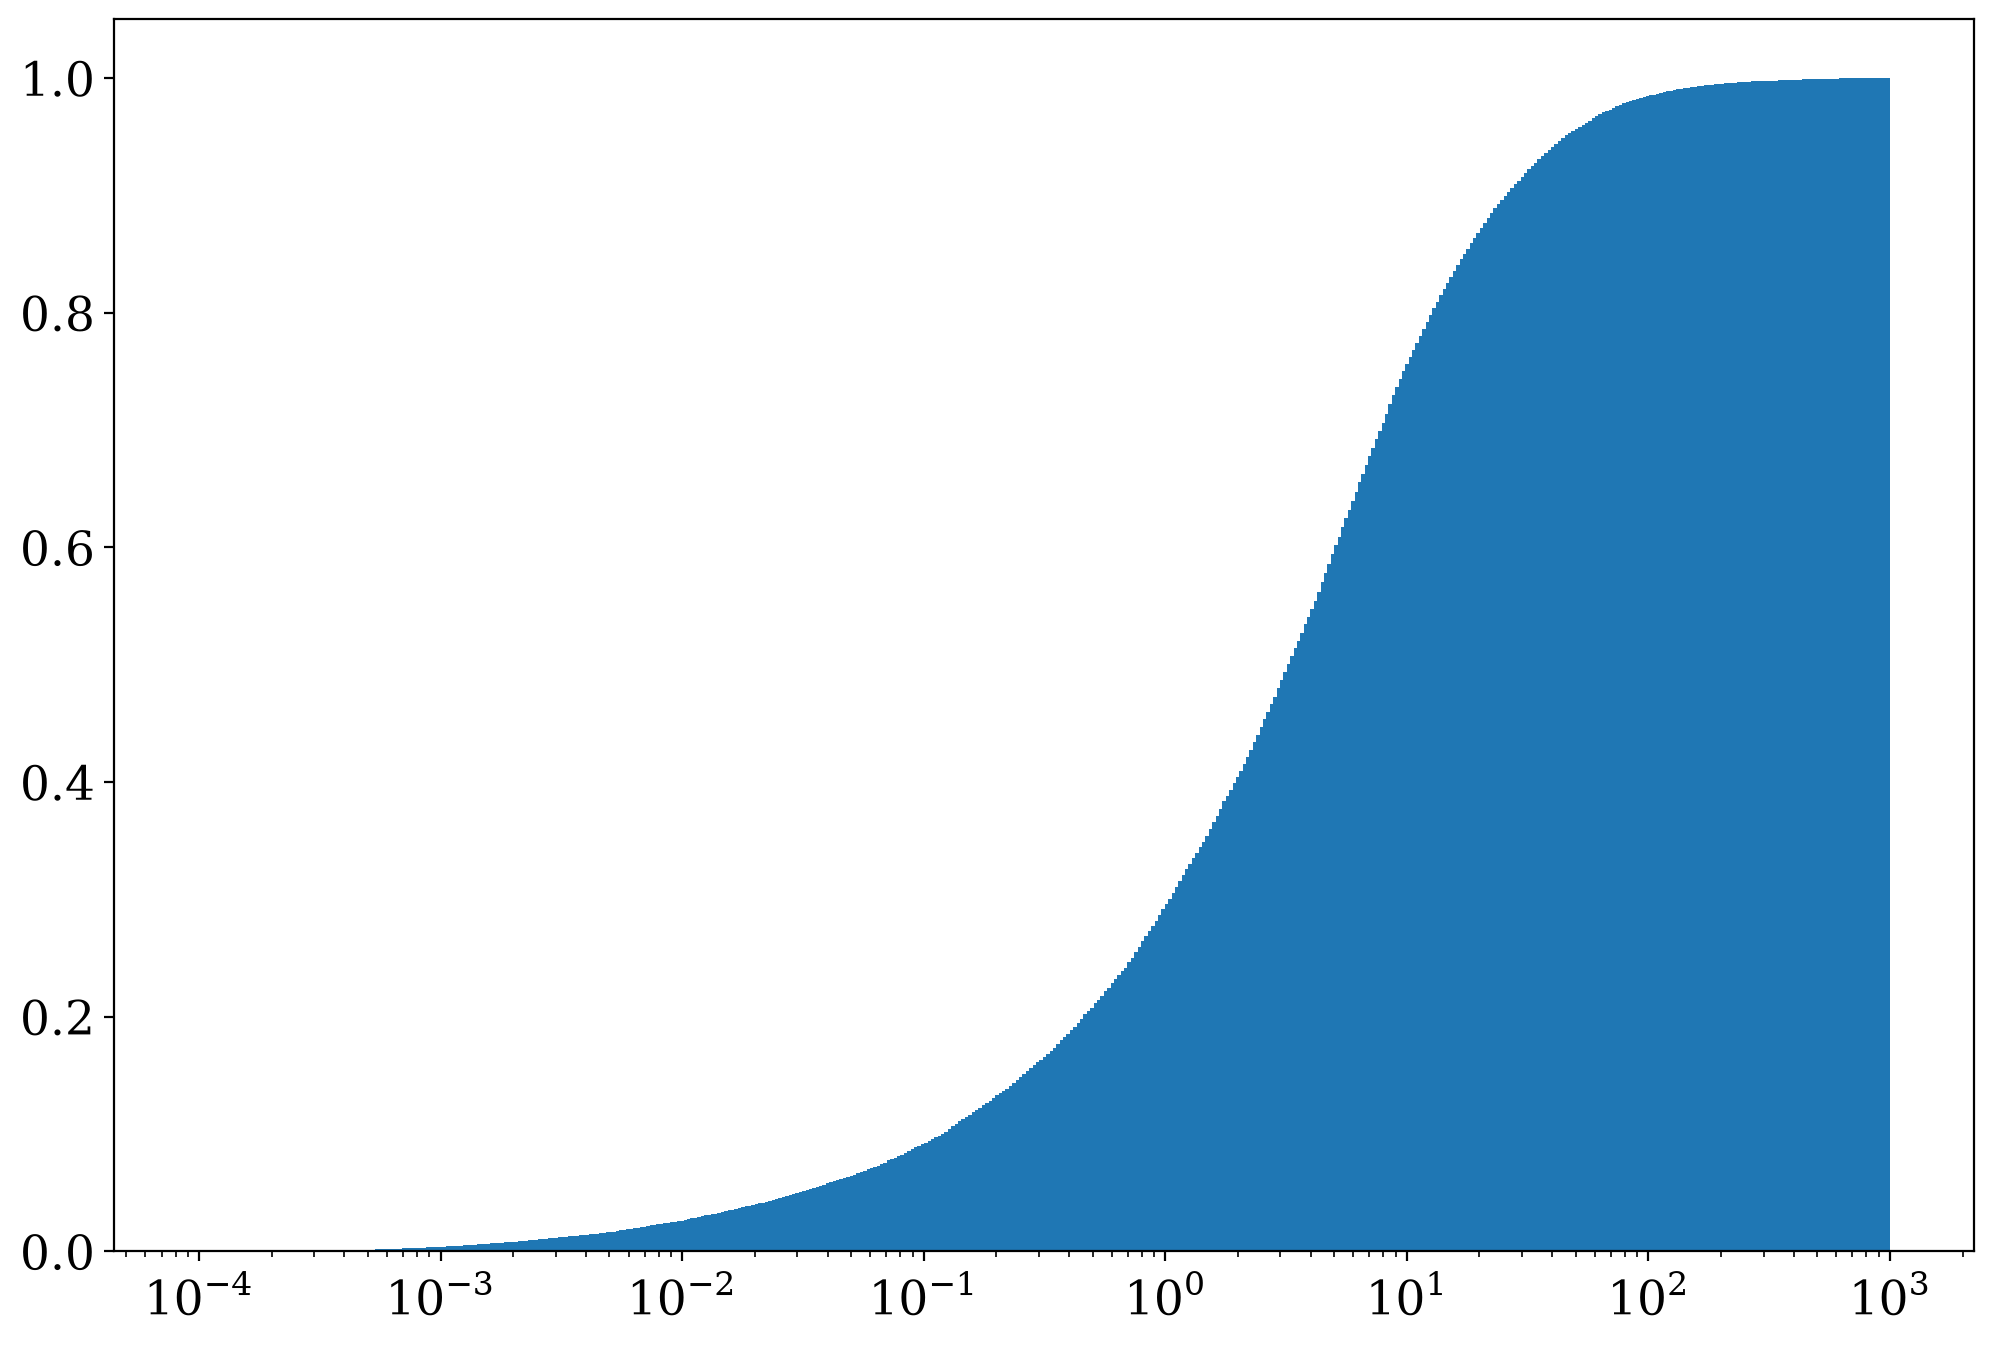

In [56]:
plt.hist(sigma_m_c, cumulative=True, bins=np.logspace(-4, 3, 500), density=True, weights=pop.initC["weights"])
plt.xscale("log")

In [45]:
ranges = [(0, 1), (1e-3, 1), (0.01, 1), (0.1, 1)]
for lo, hi in ranges:
    in_range = min_ratio[(min_ratio >= lo) & (min_ratio <= hi)]
    in_range_dh = detectable_harmonics[(min_ratio >= lo) & (min_ratio <= hi)]
    in_range_weights = pop.initC["weights"][(min_ratio >= lo) & (min_ratio <= hi)]
    print(np.sum(in_range_weights[((in_range > 1e-2) & (in_range_dh >= 2))]) / np.sum(in_range_weights) * 100)

2.348066994123517
94.6580839559977
100.0
100.0


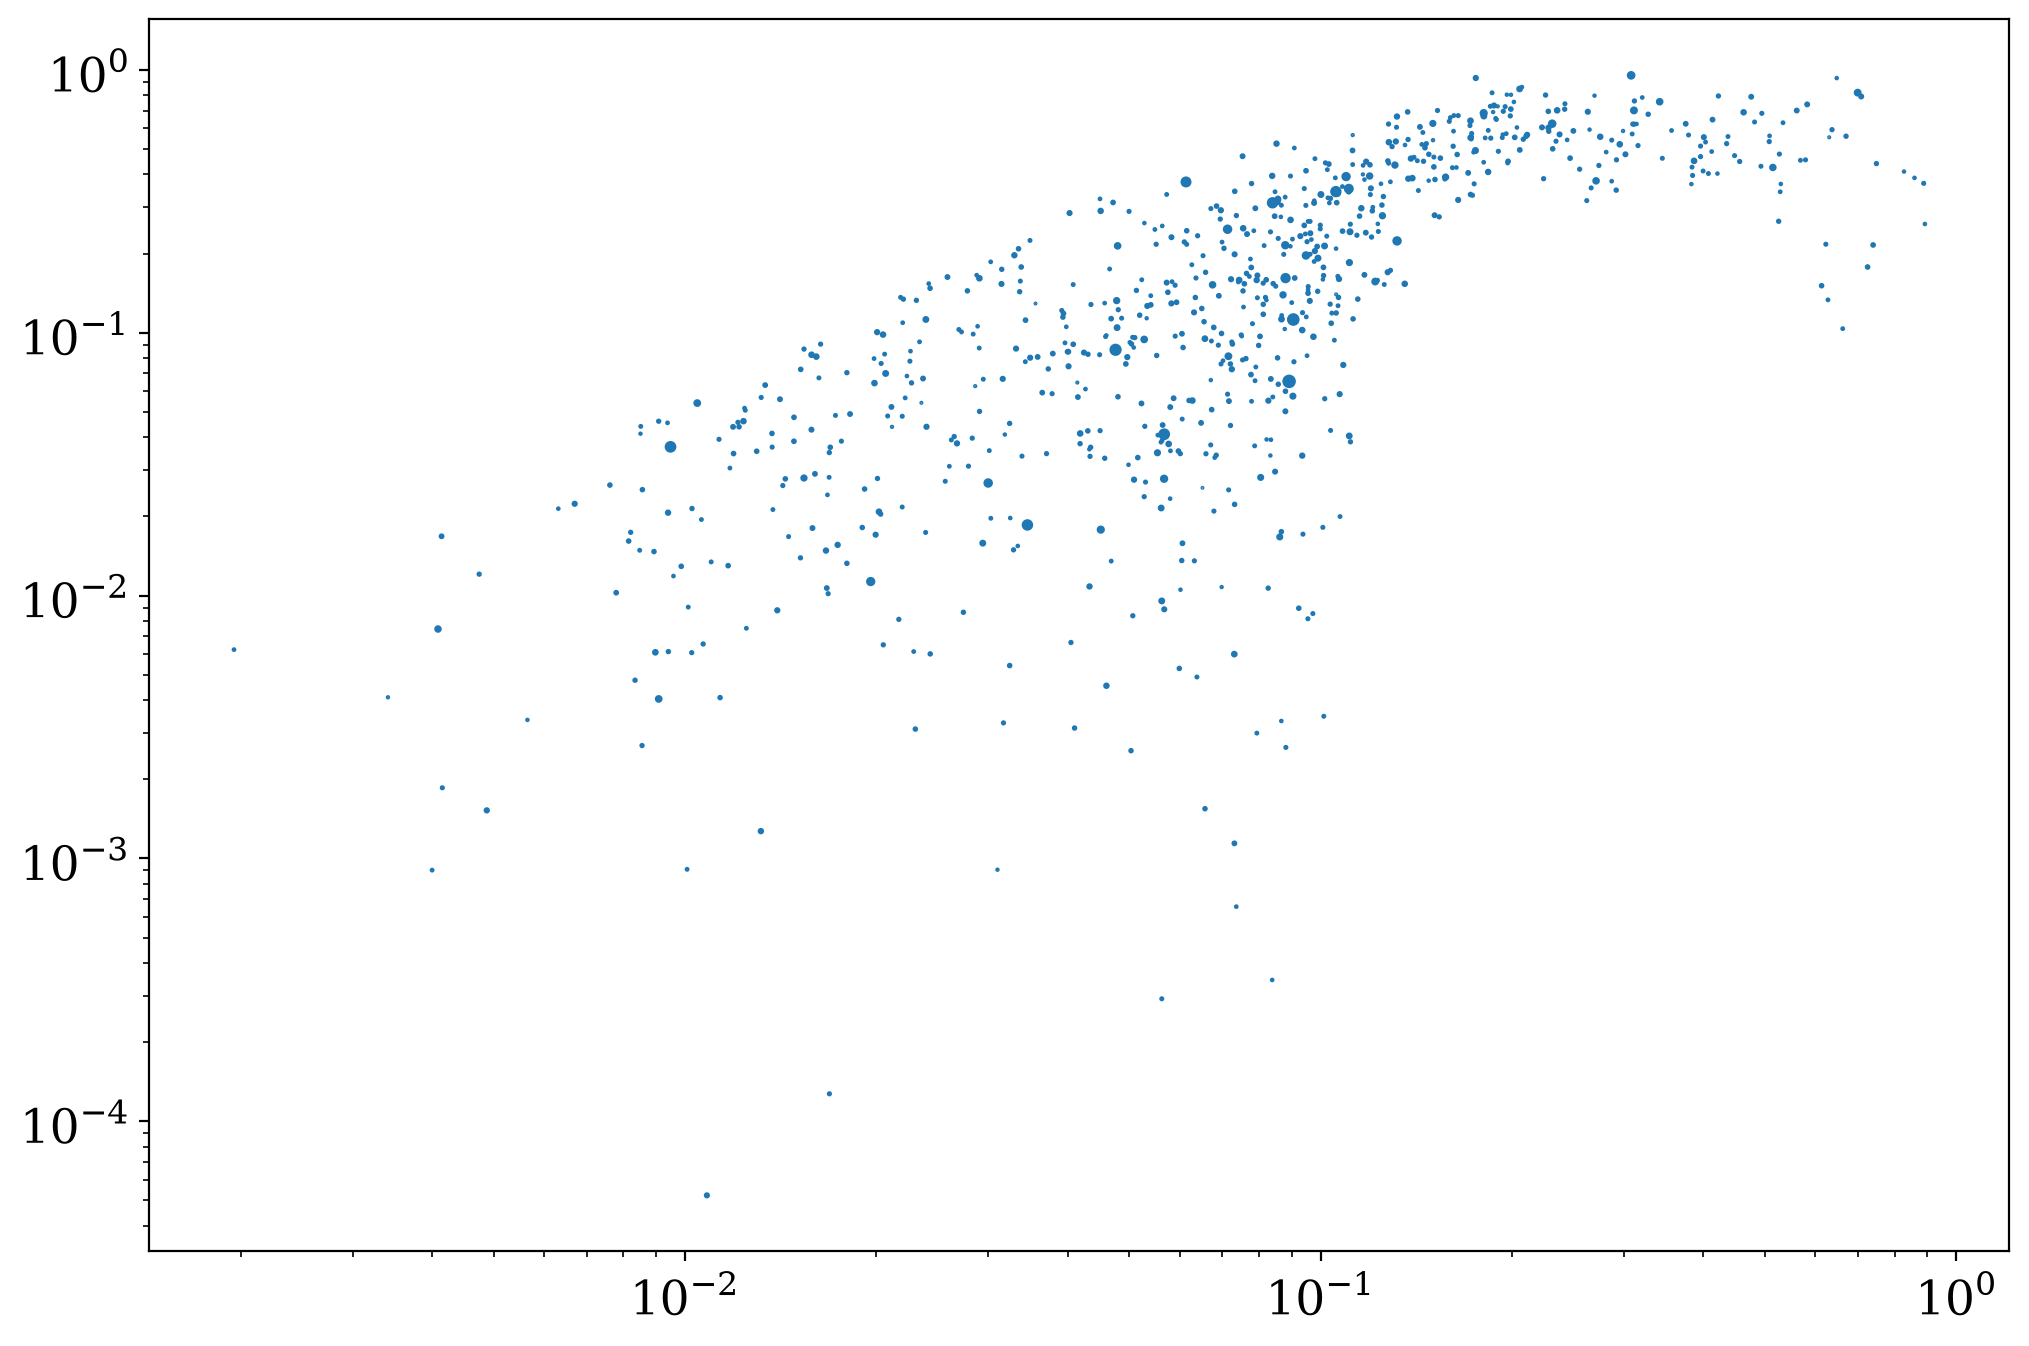

In [157]:
plt.scatter(sources.ecc[min_ratio > 0], min_ratio[min_ratio > 0], s=20 * pop.initC["weights"][min_ratio > 0])
plt.xscale("log")
plt.yscale("log")

In [133]:
snr_ratio - snr_uncertainty > 0.01

array([False, False, False, ..., False, False, False], shape=(40457,))

In [130]:
snr_uncertainty

array([2.00081009, 0.67625843, 0.48317602, ..., 1.15830565, 0.90784628,
       2.5251525 ], shape=(40457,))

In [122]:
np.unique(detectable_harmonics, return_counts=True)

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  18,  20,  21,  24,  25,  26,  29,  30,  31,
         32,  34,  35,  38,  39,  40,  77,  86,  94, 104, 111, 119, 122,
        438]),
 array([    4, 26397, 13387,   423,   102,    35,    18,    14,    13,
           21,     1,     1,     1,     1,     2,     3,     2,     3,
            4,     1,     1,     2,     2,     1,     1,     1,     1,
            2,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     2,     1]))

(array([1.51398157e+03, 2.00997843e+02, 4.33131828e+01, 1.57982183e+01,
        9.42439195e+00, 3.98070171e+00, 1.95968241e+00, 1.15113174e+00,
        1.40141247e+00, 7.82763234e-01, 4.63015850e-01, 7.91387956e-01,
        2.86779855e-01, 3.59012173e-01, 3.28290460e-01, 6.28128792e-01,
        2.28431397e-01, 2.70199173e-02, 2.74214888e-01, 2.35491963e-01,
        1.50444793e-01, 1.05450229e-01, 1.31183932e-01, 9.46356100e-02,
        1.34117795e-01, 2.70476790e-01, 2.87050995e-02, 9.25865902e-02,
        9.86890548e-02, 1.15166773e-01, 1.26995257e-01, 1.96843180e-01,
        7.08816876e-02, 7.05811872e-02, 2.35135248e-01, 1.56670347e-01,
        9.65398553e-02, 3.48772758e-02, 0.00000000e+00, 0.00000000e+00,
        1.99241923e-01, 0.00000000e+00, 2.23142217e-02, 2.82655911e-01,
        3.60970219e-01, 0.00000000e+00, 0.00000000e+00, 6.31949301e-01,
        1.74192475e-01]),
 array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
        0.10204082, 0.12244898, 0.14285714

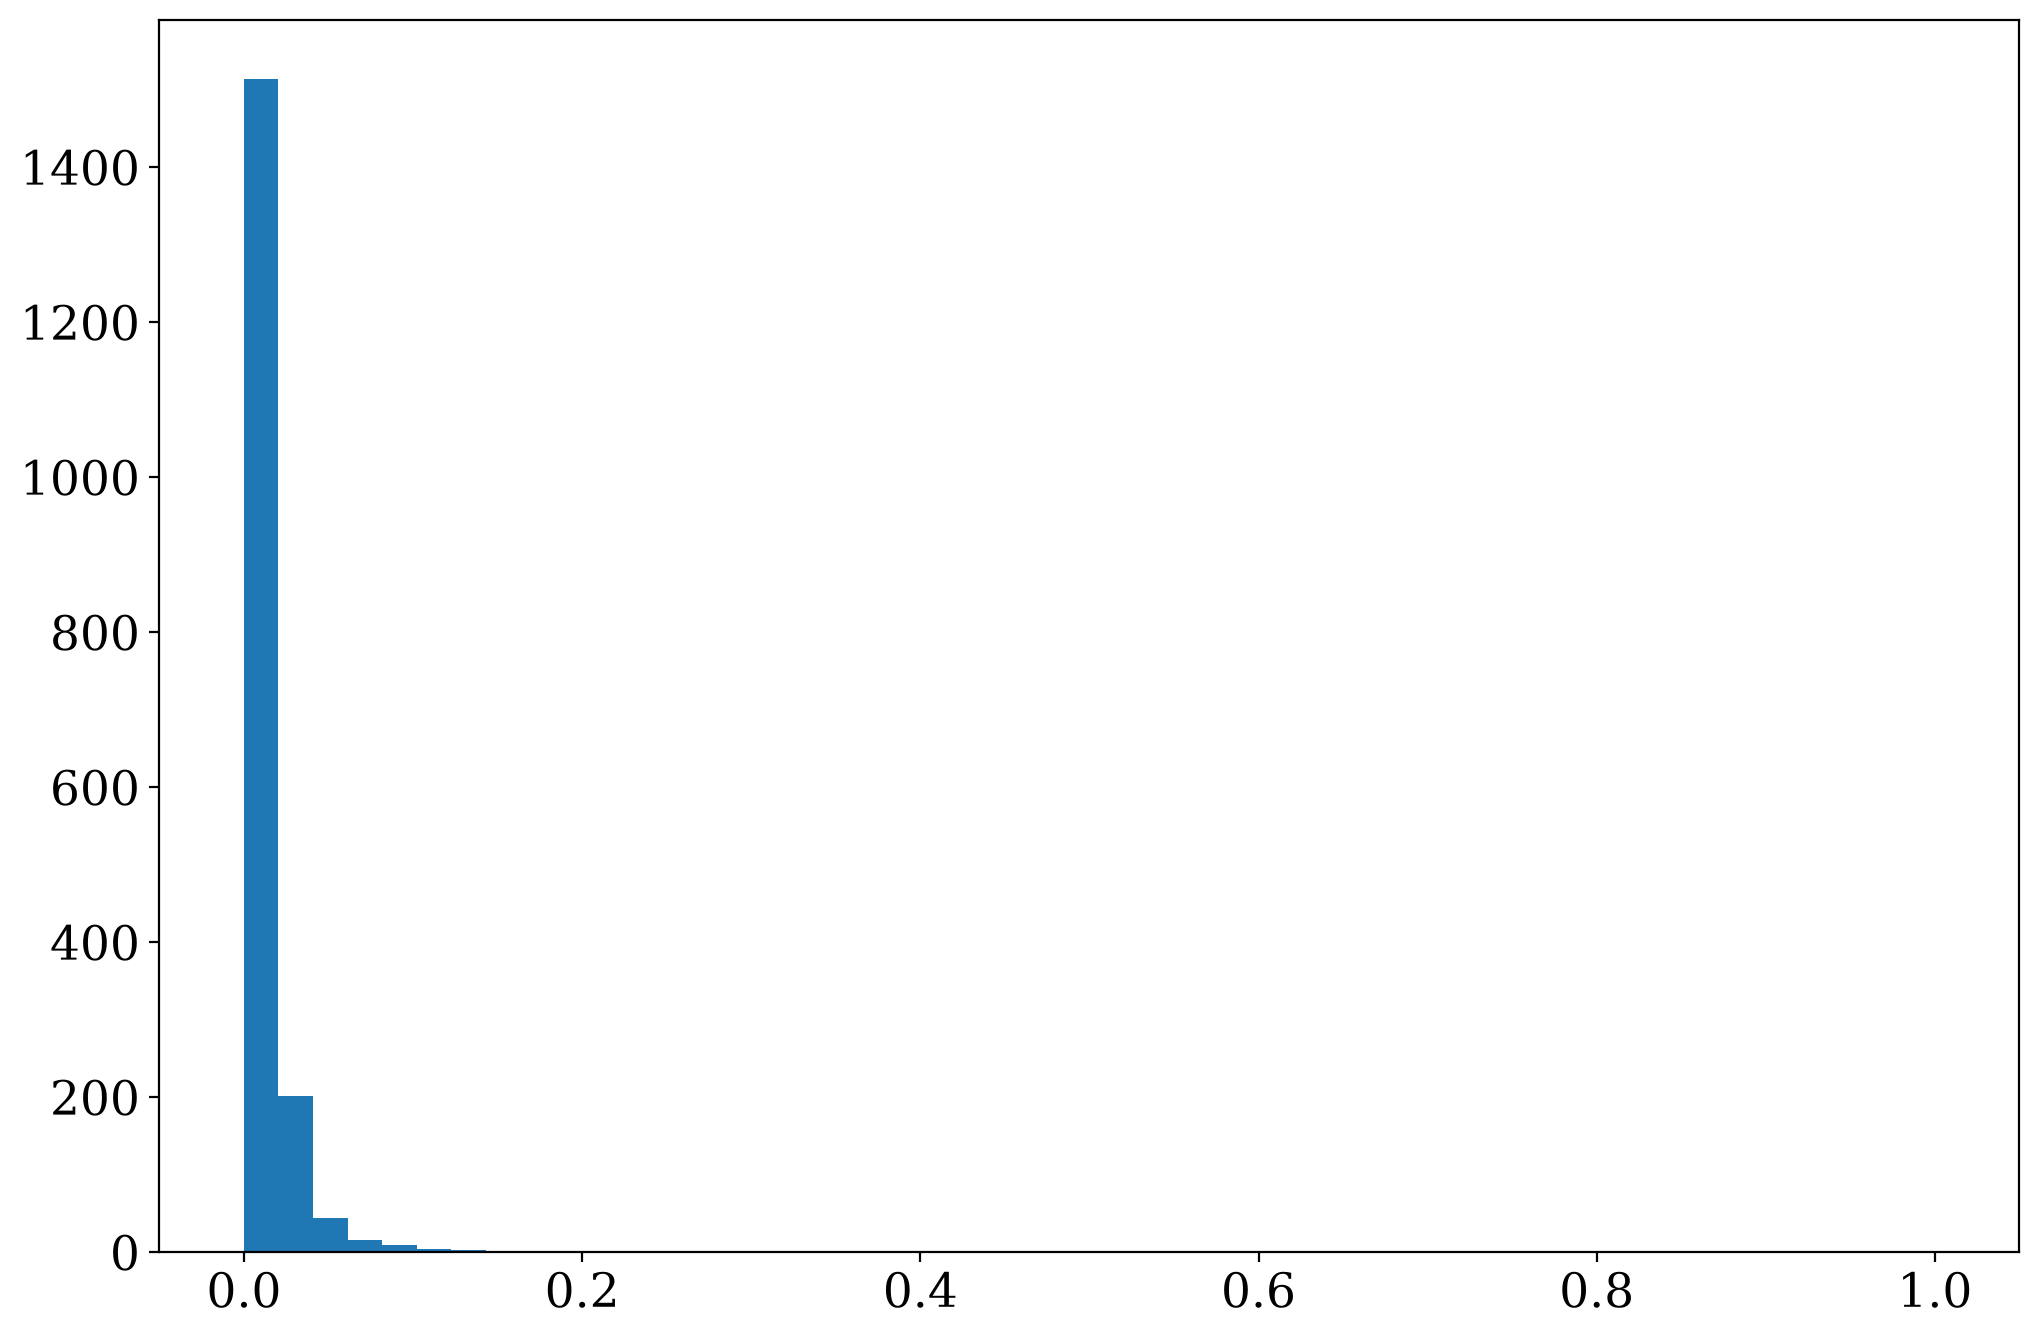

In [129]:
plt.hist(sources.ecc, weights=pop.initC["weights"], bins=np.linspace(0, 1, 50))

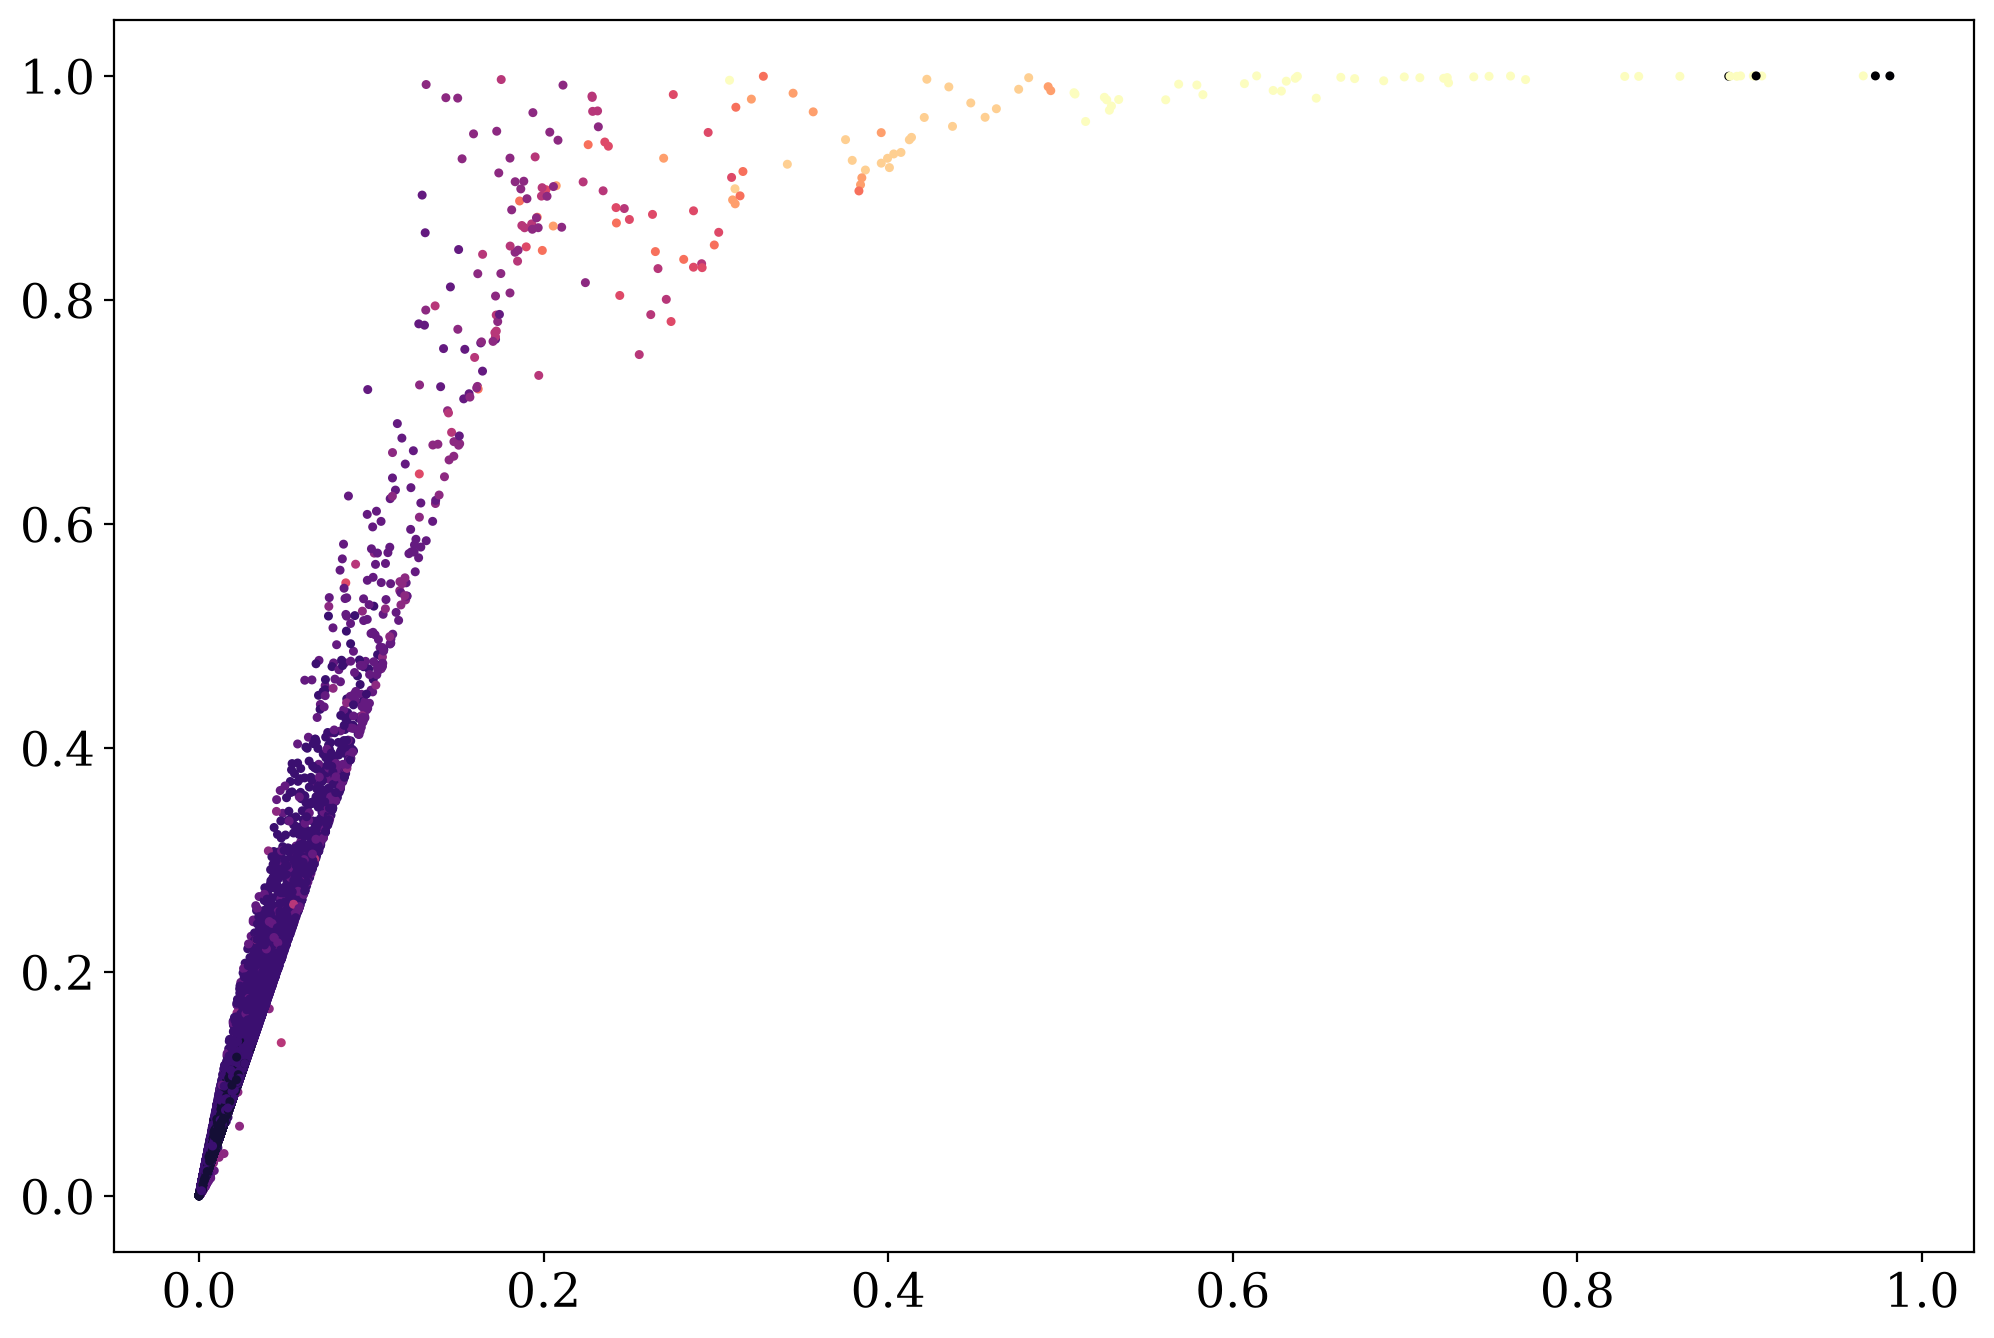

In [125]:
plt.scatter(sources.ecc, p_ecc, c=detectable_harmonics, vmin=0, vmax=10, cmap="magma", s=5)

(array([2.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 2.000e+00, 2.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 4.000e+00,
        3.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 6.000e+00, 3.000e+00,
        5.000e+00, 7.000e+00, 3.000e+00, 2.000e+00, 3.000e+00, 1.200e+01,
        1.000e+01, 9.000e+00, 1.200e+01, 1.400e+01, 1.100e+01, 2.600e+01,
        2.200e+01, 1.900e+01, 2.100e+01, 2.300e+01, 3.300e+01, 2.100e+01,
        3.300e+01, 4.400e+01, 3.300e+01, 3.500e+01, 5.000e+01, 5.000e+01,
        6.700e+01, 7.200e+01, 6.500e+01, 8.100e+01, 7.500e+01, 8.200e+01,
        8.600e+01, 1.010e+02, 1.260e+02, 1.210e+02, 1.300e+02, 1.350e+02,
        1.710e+02, 1.810e+02, 1.880e+02, 2.020e+02, 2.350e+02, 2.630e+02,
        2.920e+02, 3.150e+02, 3.700e+02, 3.810e+02, 4.480e+02, 4.490e+02,
        4.900e+02, 5.690e+02, 5.390e+02, 6.110e+02, 6.500e+02, 6.400e+02,
        8.030e+02, 8.280e+02, 8.940e+0

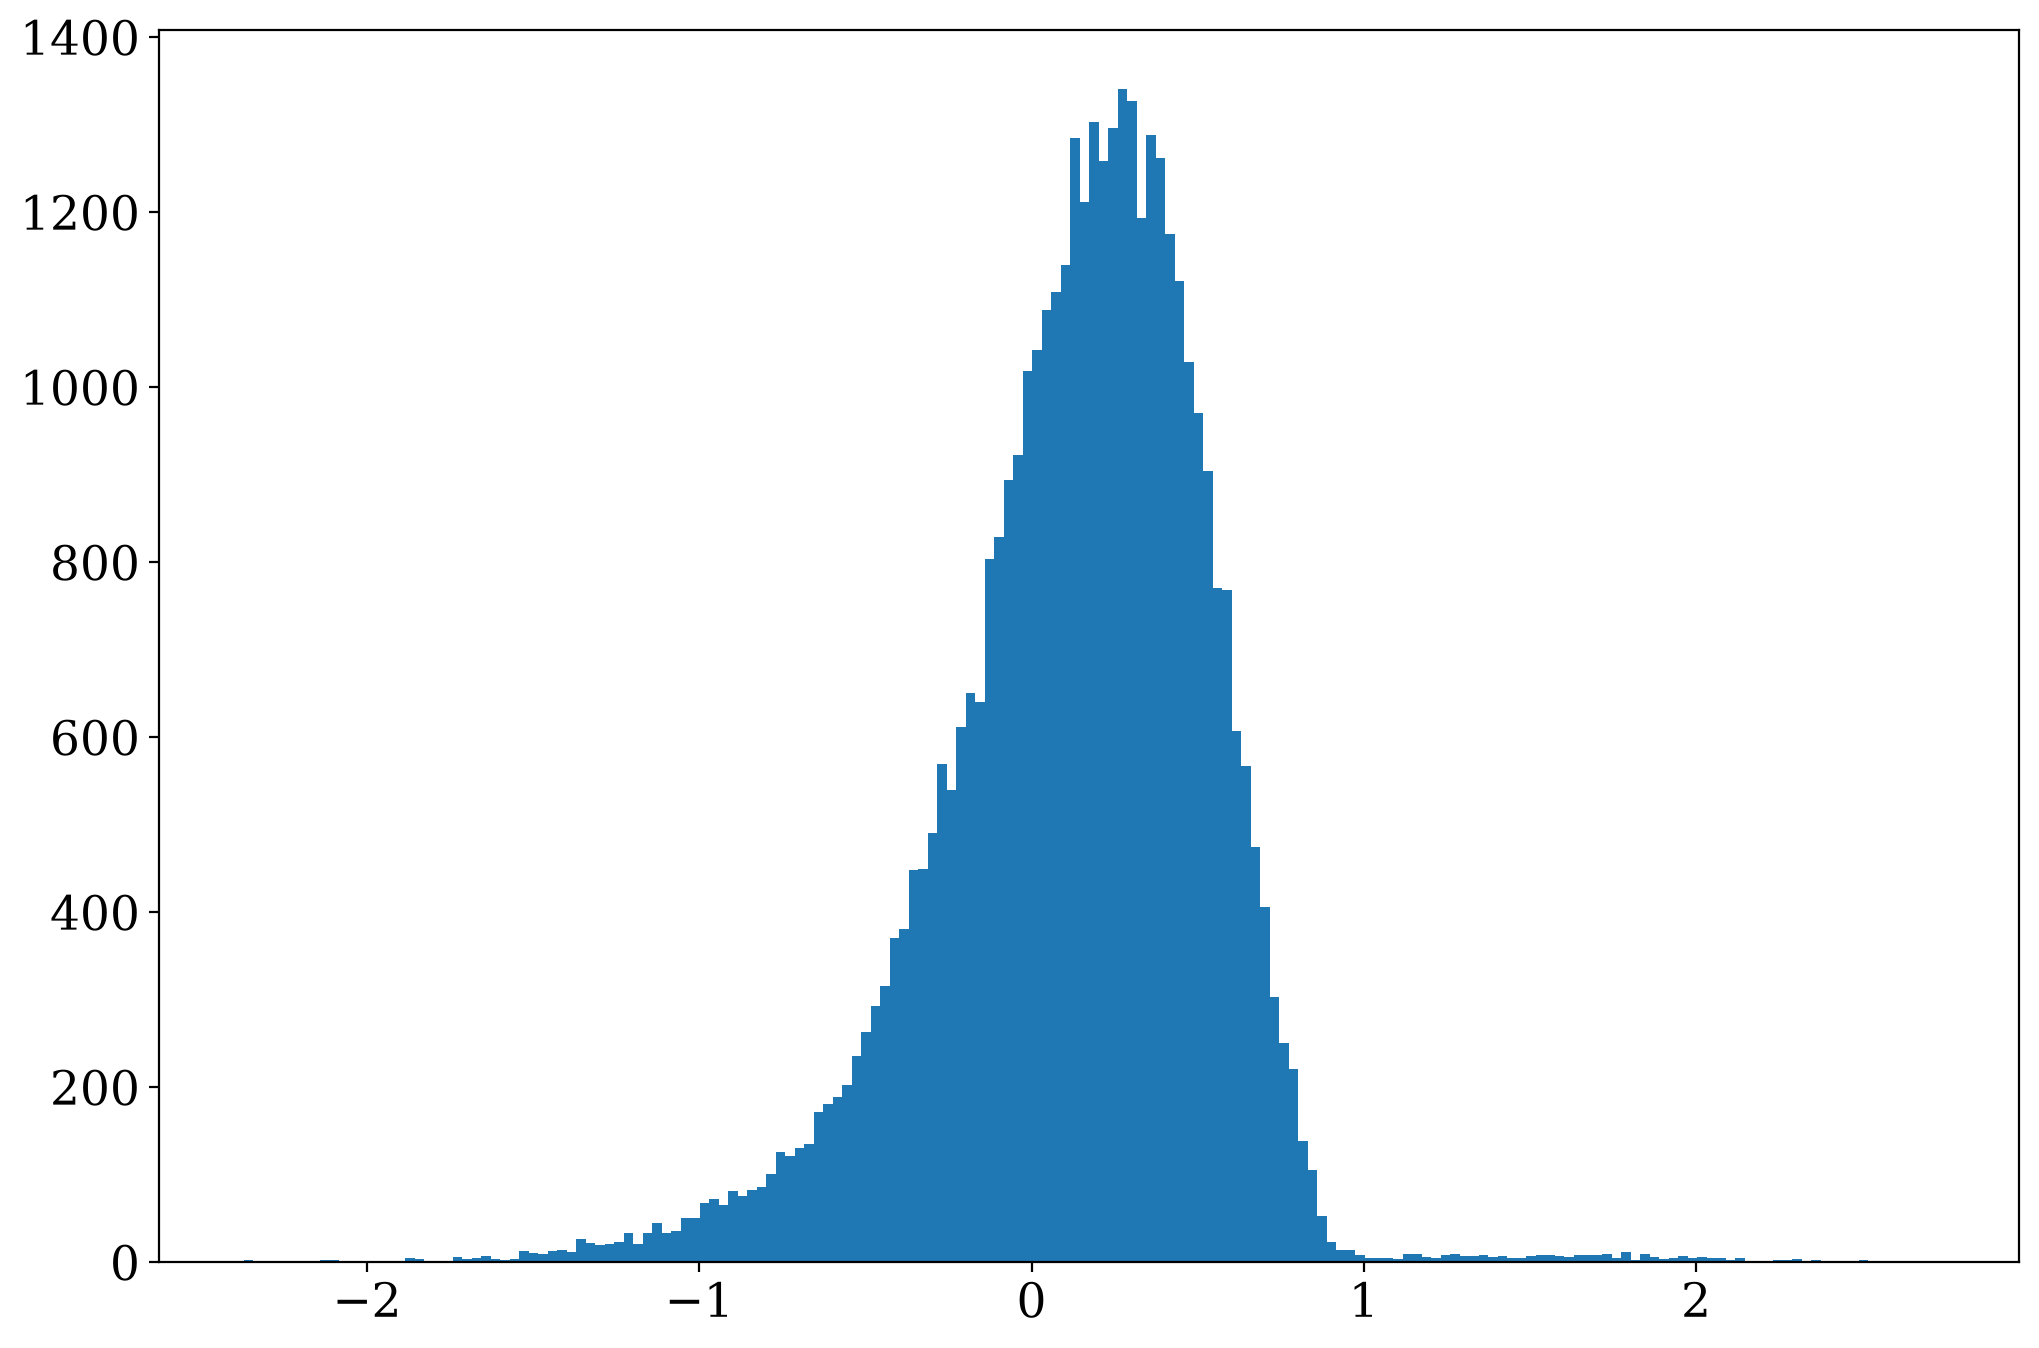

In [104]:
plt.hist(np.log10(ecc_uncertainty), bins="auto")

In [114]:
def estimate_scale_height_cdf(
        z, plot=False, fig=None, ax=None, show=True,
        label="", colour="black", scale_height_loc=None,
        R=None, Rlims=(7.5, 8.5), verbose=False, weight_bins=False, lw=4, zorder=1, **kwargs):
    """Estimate the scale height of a distribution given z-positions using the cumulative distribution function (CDF).
    This method does not assume a model, but instead just finds the z-value at which the CDF reaches 1 - 1/e ~ 0.63, which corresponds to the scale height for an exponential distribution."""
    z = np.abs(z)
    if R is not None:
        R = R.to(u.kpc).value if hasattr(R, 'unit') else R
        mask = (R >= Rlims[0]) & (R < Rlims[1])
        if verbose:
            print(len(z), "objects before Rlims")
        z = z[mask]
        if verbose:
            print(len(z), "objects in Rlims")

    if hasattr(z, 'unit'):
        z = z.to(u.kpc).value

    # calculate empirical CDF without any binning
    sorted_z = np.sort(z)
    cdf = np.arange(1, len(sorted_z) + 1) / len(sorted_z)

    scale_height = sorted_z[cdf >= (1 - 1 / np.e)][0]


    if plot:
        if fig is None or ax is None:
            fig, ax = plt.subplots()

        # interpolate cdf for plotting
        subsample_z = np.geomspace(sorted_z.min(), sorted_z.max(), 1000)
        cdf_interp = np.interp(subsample_z, sorted_z, cdf)

        ax.plot(subsample_z, cdf_interp, label=label, color=colour, lw=lw, zorder=zorder)

        if scale_height_loc is not None:
            loc = 0.5 if scale_height_loc is None else scale_height_loc
            ax.axvline(scale_height, color=colour, ls='--', alpha=0.75, lw=lw/2)
            ax.annotate(f"{scale_height * 1000:.0f} pc", xy=(scale_height, loc), fontsize=16,
                        rotation=0, color=colour, ha='center', va='top',
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colour, lw=lw/2))

        ax.set(
            xlabel="Distance from the Galactic plane, |z| (kpc)",
            ylabel=kwargs.pop('ylabel', r'$F(z)$'),
            xscale=kwargs.pop('xscale', 'log'),
            **kwargs
        )
        ax.set_xlabel(ax.get_xlabel(), fontsize=18)
        ax.legend(fontsize=16)

        if show:
            plt.show()

        return scale_height, None, fig, ax
    else:
        return scale_height, None, None, None

In [127]:
np.sum(pop.initC["weights"][(np.abs(pop.final_pos[:, 2]) > 10 * u.kpc)]) / np.sum(pop.initC["weights"])

np.float64(0.012693874278977724)

In [128]:
np.sum(pop.initC["weights"][(np.abs(pop.initial_galaxy.z) > 10 * u.kpc)]) / np.sum(pop.initC["weights"])

np.float64(0.0)

/tmp/ipykernel_1209086/4266997424.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=16)



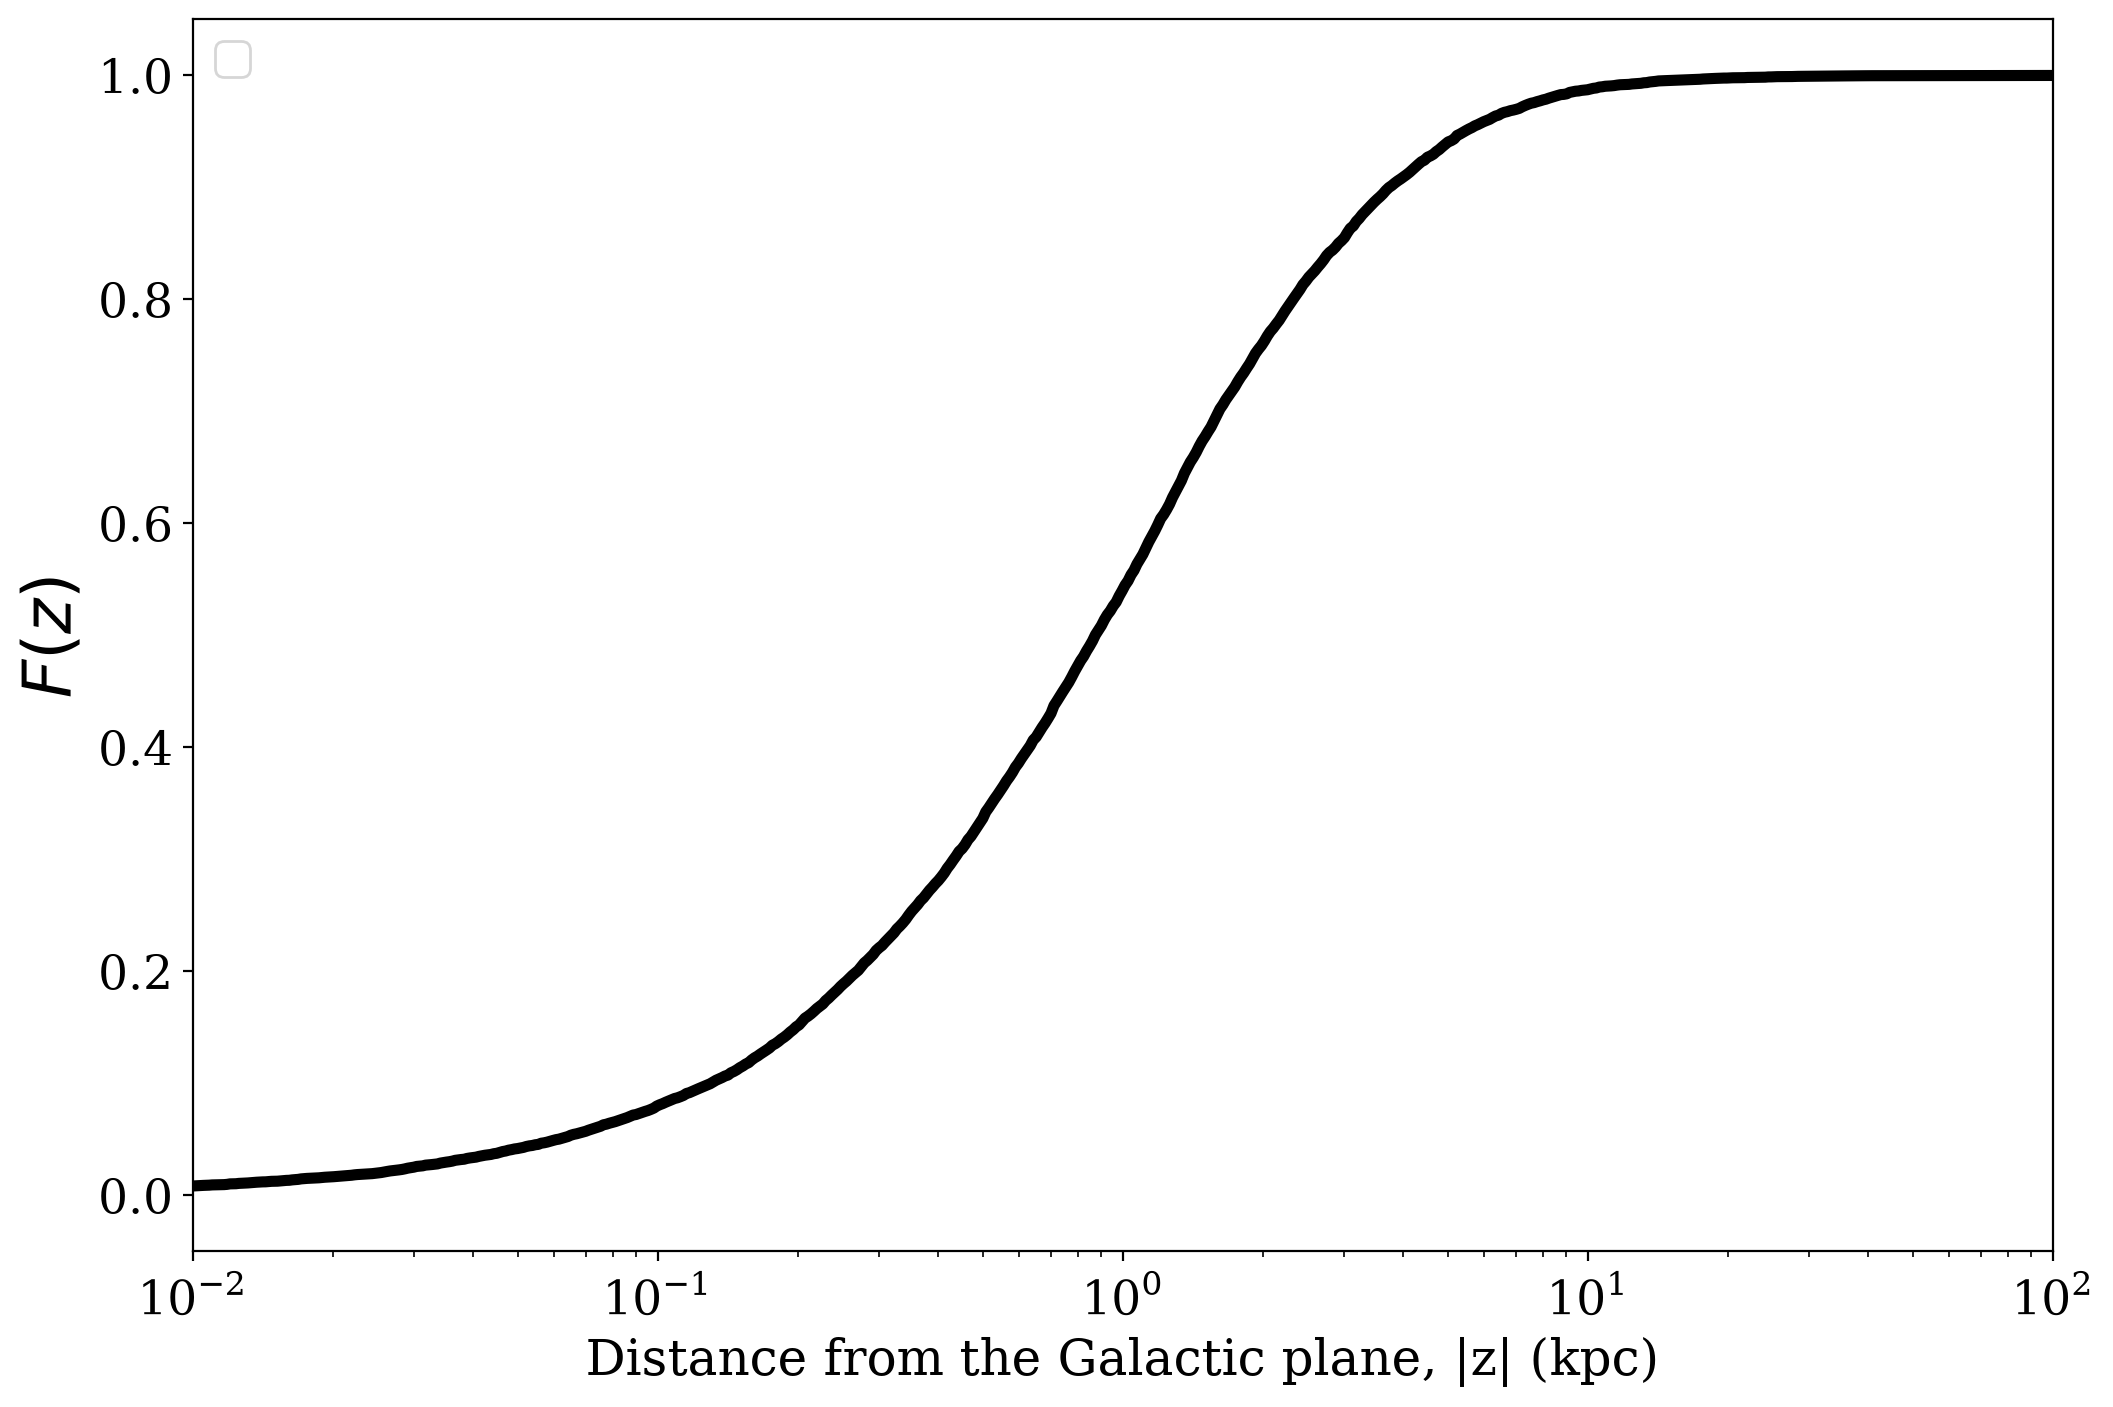

(np.float64(1.3142811925336093), None, <Figure size 1200x800 with 1 Axes>, <Axes: xlabel='Distance from the Galactic plane, |z| (kpc)', ylabel='$F(z)$'>)


In [122]:
weighted_z = np.random.choice(pop.final_pos[:, 2], size=50000, p=pop.initC["weights"] / np.sum(pop.initC["weights"]), replace=True)
print(estimate_scale_height_cdf(weighted_z, plot=True, xlim=(1e-2, 1e2)))

In [2]:
fiducial = {'xi': 1.0, 'bhflag': 1, 'neta': 0.5, 'windflag': 3, 'wdflag': 1, 'alpha1': 1.0, 
            'pts1': 0.001, 'pts3': 0.02, 'pts2': 0.01, 'epsnov': 0.001, 'hewind': 0.5, 
            'ck': 1000, 'bwind': 0.0, 'lambdaf': 0.0, 'mxns': 3.0, 'beta': -1.0,
            'tflag': 1, 'acc2': 1.5, 'grflag' : 1, 'remnantflag': 4, 'ceflag': 0, 
            'eddfac': 1.0, 'ifflag': 0, 'bconst': 3000, 'sigma': 265.0, 'gamma': -2.0, 
            'pisn': 45.0, 'natal_kick_array' : [[-100.0,-100.0,-100.0,-100.0,0.0], [-100.0,-100.0,-100.0,-100.0,0.0]], 
            'bhsigmafrac' : 1.0, 'polar_kick_angle' : 90, 
            'qcrit_array' : [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
            'cekickflag' : 2, 'cehestarflag' : 0, 'cemergeflag' : 0, 'ecsn' : 2.5, 
            'ecsn_mlow' : 1.8, 'aic' : 1, 'ussn' : 0, 'sigmadiv' :-20.0, 'qcflag' : 5,
            'eddlimflag' : 0, 
            'fprimc_array' : [2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0],
            'bhspinflag' : 0, 'bhspinmag' : 0.0, 'rejuv_fac' : 1.0, 'rejuvflag' : 0, 
            'htpmb' : 1, 'ST_cr' : 1, 'ST_tide' : 1,
            'bdecayfac' : 1, 'rembar_massloss' : 0.5, 'kickflag' : 5, 'zsun' : 0.014, 
            'bhms_coll_flag' : 0, 'don_lim' : -1,
            'acc_lim' : -1, 'rtmsflag' : 0, 'wd_mass_lim': 1}

In [3]:
BSEDict = cosmic.utils.parse_inifile("../src/params.ini")[0]

In [7]:
for k in fiducial:
    if fiducial[k] != BSEDict[k]:
        print(f"Parameter {k} differs")
        print(f"   Frank={fiducial[k]}, Tom={BSEDict[k]}")

Parameter xi differs
   Frank=1.0, Tom=0.5
Parameter bhflag differs
   Frank=1, Tom=4
Parameter alpha1 differs
   Frank=1.0, Tom=[1.0, 1.0]
Parameter beta differs
   Frank=-1.0, Tom=0.125
Parameter ceflag differs
   Frank=0, Tom=1
Parameter eddfac differs
   Frank=1.0, Tom=10
Parameter ifflag differs
   Frank=0, Tom=1
Parameter pisn differs
   Frank=45.0, Tom=-4
Parameter cemergeflag differs
   Frank=0, Tom=1
Parameter ecsn differs
   Frank=2.5, Tom=2.25
Parameter ecsn_mlow differs
   Frank=1.8, Tom=1.6
Parameter ussn differs
   Frank=0, Tom=1
Parameter acc_lim differs
   Frank=-1, Tom=[-1, -1]
